<h1 style="text-align: center;">Supports pour le projet </h1>

Outre le fait de récupérer les données, ce notebook propose quelques conseils pour réussir le projet. Il précise, en autre, les classes et fonctions disponibles dans les guides que vous devez utiliser.

# Initialisation pour Colab

In [1]:
#from google.colab import drive
#drive.mount('/content/gdrive')

In [2]:
#import sys
#my_local_drive='/content/gdrive/My Drive/Colab Notebooks/ML_FDS'
#sys.path.append(my_local_drive)

In [3]:
#%cd $my_local_drive


Il est conseillé d'utiliser a minima ces librairies.

In [4]:
import os
import warnings
os.environ['XLA_FLAGS'] = '--xla_gpu_force_compilation_parallelism=1'
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['NVCC_PREPEND_FLAGS'] = '-w'
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

import pandas as pd
import re
import numpy as np
import random
import zipfile
import requests
import io
import math
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras import layers, models, Model, Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, 
    Dropout, TextVectorization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Mean
from tensorflow.keras.models import load_model

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Pour utiliser au mieux le GPU
AUTOTUNE = tf.data.AUTOTUNE


In [5]:

# definir une seed pour "essayer" de diminuer les variations (enlever si recherche d'un modéle)
seed = 42

random.seed(seed)
np.random.seed(seed)


# Récupération du jeu de données

Le jeu de données a été créé à partir de données de la plateforme de partage de photos [Flickr](https://www.flickr.com). 4 catégories de 150 images et textes ont été créées :    
- bike
- ball
- water
- dog  

Chacune des catégories contient 150 images et textes associés.
La cellule suivante permet d'extraire le jeu de données qui sera organisé de la manière suivante :     

  flickr_subset2
├─ captions.csv  
├─ captions  
│  ├─ bike100.txt  
│  ├─ bike200.txt  
│  └─ ...   
└─ images  
   ├─ bike  
   │   ├─ bike150.png  
   │  ├─ bike151.png  
   │  └─ ...  
   ├─ ball  
   │  ├─ ball150.png  
   │  ├─ ball151.png  
   │  └─ ...  
   ├─ water  
   │  ├─ water150.png  
   │  ├─ water151.png  
   │  └─ ...  
   └─ dog  
      ├─ dog150.png  
      ├─ dog151.png  
      └─ ...  

 Le fichier `caption.csv`permet de faire la correspondance entre les images, les textes. Il contient le label de la classe (e.g. dog, water, ball, bike) et le texte associé à l'image.   


In [6]:
url = "https://www.lirmm.fr/~poncelet/Ressources/flickr_long_subset.zip"
target_dir = "flickr_subset2"

# Vérifie si le dossier existe déjà
if os.path.exists(target_dir) and os.path.isdir(target_dir):
    print("Données déjà disponibles dans :", target_dir)
else:
    print("Téléchargement de flickr_long_subset.zip...")
    response = requests.get(url)
    if response.status_code == 200:
        print("Téléchargement réussi. Extraction...")
        with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
            # Extraire sans ajouter de sous-dossier supplémentaire
            for member in zip_ref.namelist():
                # Corrige les chemins pour ignorer un éventuel prefixe flickr_subset2/
                member_path = member
                if member.startswith("flickr_long_subset/"):
                    member_path = member[len("flickr_long_subset/"):]
                target_path = os.path.join(target_dir, member_path)

                # Si c'est un répertoire, on le crée
                if member.endswith("/"):
                    os.makedirs(target_path, exist_ok=True)
                else:
                    os.makedirs(os.path.dirname(target_path), exist_ok=True)
                    with zip_ref.open(member) as source, open(target_path, "wb") as target:
                        target.write(source.read())
        print(f"Données extraites dans : {target_dir}")
    else:
        print("Échec du téléchargement. Code HTTP :", response.status_code)


Données déjà disponibles dans : flickr_subset2


# Fonctions, classes et variables utiles pour la suite

Les cellules suivantes contiennent des fonctions et des classes qui seront utiles pour votre projet. Les classes sont extraites des différents guides qui sont mis à votre disposition. Nous les recopions ici pour éviter de les chercher.   

**Attention :** il est important que vous compreniez bien le fonctionnement des classes, aussi n'hésitez pas à vous reporter à [Ressources Deep Learning](https://gite.lirmm.fr/poncelet/deeplearning) où vous de plus amples informations sur leur fonctionnement et leur usage.

In [7]:
# FONCTIONS UTILES

def preview_images_from_dir(image_dir, image_size=(224, 224), n=12,
                            subset="training", seed=123):
    """
    Affiche n images avec leurs labels à partir d'un dossier
    (flow_from_directory).
    N'utilise PAS train_gen pour ne pas en avancer l'index.
    """
    # Générateur léger juste pour l'aperçu
    # Ici il y a une bonne indication si vous regardez bien pour la classif :)
    preview_datagen = ImageDataGenerator(validation_split=0.2, rescale=1./255)

    preview_gen = preview_datagen.flow_from_directory(
        image_dir,
        target_size=image_size,
        batch_size=n,
        class_mode="categorical",
        subset=subset,
        shuffle=True,
        seed=seed
    )

    imgs, y = next(preview_gen)    # imgs: (n, H, W, 3), y: one-hot
    class_names = list(preview_gen.class_indices.keys())
    labels = np.argmax(y, axis=1)

    rows = 3
    cols = int(np.ceil(n / rows))
    plt.figure(figsize=(4*cols, 4*rows))
    for i in range(min(n, imgs.shape[0])):
        plt.subplot(rows, cols, i+1)
        plt.imshow(imgs[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()
        #Histogramme des images par classe
    counts = preview_gen.classes
    class_names = list(preview_gen.class_indices.keys())

    # Compter le nombre d'images par classe
    unique, class_counts = np.unique(counts, return_counts=True)

    plt.figure(figsize=(8, 5))
    plt.bar(class_names, class_counts)
    plt.xlabel("Classes")
    plt.ylabel("Nombre d'images")
    plt.title("Distribution des images par classe")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



In [8]:

#preview_images_from_dir("flickr_subset2/images")


Classes utiles pour la suite.

In [9]:
# Classes à utiliser pour la partie classification de texte. Laquelle ?
@register_keras_serializable()
class SelectFirstToken (layers.Layer):
  # Retourne le premier mot
    def call(self, inputs):
        return inputs[:, 0] # (batch, embed_dim)

@register_keras_serializable()
class SelectMean(layers.Layer):
  # Retourne la moyenne des mots - bien si pas trop de PAD - chaînes même taille
    def call(self, inputs):
        # inputs: (batch, seq_len, embed_dim)
        return tf.reduce_mean(inputs, axis=1)  # (batch, embed_dim)


@register_keras_serializable()
class MaskedMean(layers.Layer):
  # Retourne la moyenne des mots sans être trop influencé par PAD
    def call(self, inputs):
        seq_out, token_ids = inputs   # (B,L,D), (B,L)
        mask = tf.cast(tf.not_equal(token_ids, 0), seq_out.dtype)  # PAD=0
        mask = tf.expand_dims(mask, -1)        # (B,L,1)
        summed = tf.reduce_sum(seq_out * mask, axis=1)             # (B,D)
        counts = tf.reduce_sum(mask, axis=1)                        # (B,1)
        return summed / tf.maximum(counts, 1.0)


# Classe utile pour la partie Clip mais il fallait bien regarder pour la trouver
@register_keras_serializable()
class L2Normalize(layers.Layer):
    def __init__(self, axis=-1, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.math.l2_normalize(inputs, axis=self.axis)

    def get_config(self):
        config = super().get_config()
        config.update({"axis": self.axis})
        return config

# PARTIE SMALL_BERT = COPIE DU NOTEBOOK
# ============================
# PositionalEmbedding Layer
# ============================
@tf.keras.utils.register_keras_serializable()
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(input_dim=vocab_size,
                                                 output_dim=embed_dim)
        self.position_embeddings = layers.Embedding(input_dim=sequence_length,
                                                    output_dim=embed_dim)
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(0, length)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        return tf.not_equal(inputs, 0)

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "vocab_size": self.vocab_size,
            "embed_dim": self.embed_dim,
        })
        return config

# ============================
# TransformerBlock
# ============================
@tf.keras.utils.register_keras_serializable()
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads,ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True
        self.att = layers.MultiHeadAttention(num_heads=num_heads,
                                             key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False, mask=None):
        seq_len = tf.shape(inputs)[1]
        attn_mask = None
        if mask is not None:
            attn_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.float32)
            attn_mask = tf.tile(attn_mask, [1, seq_len, 1])

        attn_output = self.att(inputs, inputs, inputs, attention_mask=attn_mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

        def get_config(self):
            config = super().get_config()
            config.update({
                "embed_dim": self.att.key_dim,
                "num_heads": self.att.num_heads,
                "ff_dim": self.ffn.layers[0].units,
                "dropout_rate": self.dropout1.rate,
            })
            return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)


# ============================
# SmallBERT encoder
# ============================
@register_keras_serializable()
class SmallBERT(tf.keras.Model):
    def __init__(self, sequence_length, vocab_size, embed_dim, num_heads,
                 ff_dim, num_layers, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.num_layers = num_layers

        self.pos_embedding = PositionalEmbedding(sequence_length, vocab_size,
                                                 embed_dim)

        self.transformer_blocks = [
            TransformerBlock(embed_dim,
                             num_heads, ff_dim) for _ in range(num_layers)
        ]
        self.layernorm = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout = tf.keras.layers.Dropout(0.1)

    def call(self, inputs, training=False):
        x = self.pos_embedding(inputs)
        for block in self.transformer_blocks:
            x = block(x, training=training)
        x = self.layernorm(x)
        return self.dropout(x, training=training)

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "vocab_size": self.vocab_size,
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "num_layers": self.num_layers,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)


Quelques variables qui peuvent être utiles pour le projet. Ces variables ont été définies pour l'apprentissage d'un modèle Clip réalisé avec les mêmes données. Elles devraient vous être utiles pour vos modèles. **Il est conseillé de conserver le nom des variables suivantes car nous vous donnerons un peu de code utilisant ces variables pour vous aider**.

In [10]:
# Répertoire cible pour sauvegarder vos modèles
model_dir = "./models_forclip"
os.makedirs(model_dir, exist_ok=True)

# Répertoire des données
dataset_dir = "./flickr_subset2"

# Répertoire des images
image_dir = os.path.join(dataset_dir, "images")
# Répertoire des captions
captions_dir = os.path.join(dataset_dir, "captions")

# Variables utiles
# Attention respecter bien l'ordre alphabétique des classes pour
# le générateur
class_names = ['ball', 'bike', 'dog', 'water']
# Pour les images
image_size=(224, 224)
image_shape = image_size + (3,)

# Pour les textes
sequence_length = 32
vocab_size = 10000
num_heads = 4
ff_dim = 256
num_layers = 2

# Pour les images et les textes dans le modèle CLIP
embed_dim = 128

# Partie classification d'images

La cellule suivante affiche quelques images pour vous faire une idée de ce que vous manipulez.   

**Remarque :** n'hésitez pas à aller regarder comment les images sont obtenues pour les afficher ...

On se sert de la fonction définie précedement.

Found 640 images belonging to 4 classes.


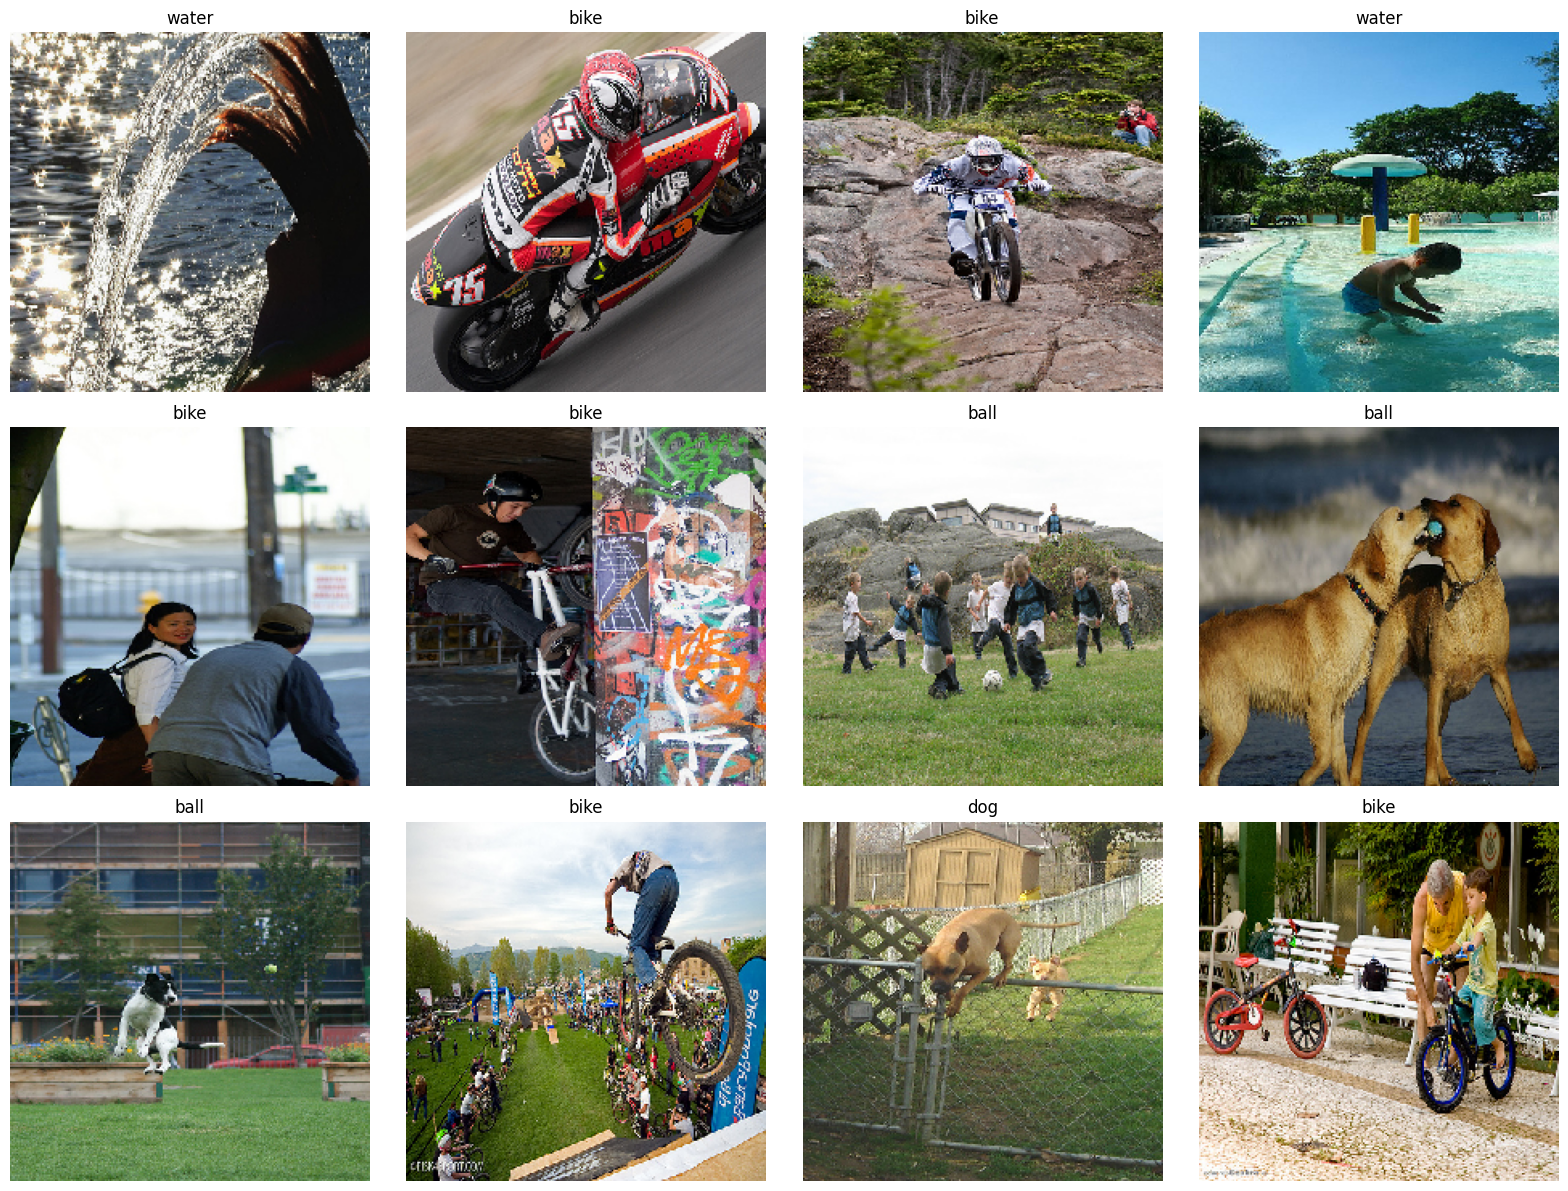

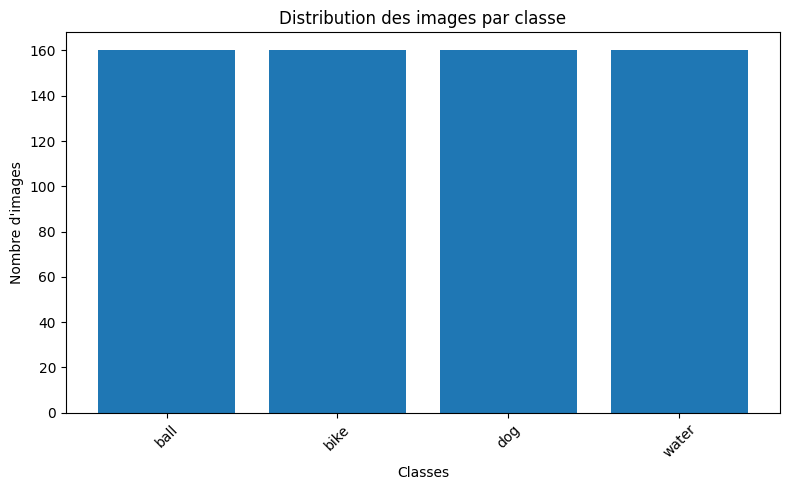

In [11]:
# Affichage des images
image_dir = "flickr_subset2/images"
image_size=(224, 224)
preview_images_from_dir(image_dir, image_size=image_size, n=12, subset="training", seed=42)

**Remarques :**
- Les images sont en couleurs et ont une taille de 224x224. Cela veut dire qu'elles prennent beaucoup de place et qu'il n'est pas possible de les charger directement en mémoire pour l'apprentissage ou la validation. Il est donc indispensable de les envoyer à la volée, i.e. par batches. **Astuce :** Chercher dans les guides comment faire pour envoyer les images à la volée à partir d'un répertoire.
- L'entraînement du modèle peut être long aussi il est préférable de le sauvegarder au fur et à mesure. Pour cela dans la cellule ci-dessous vous trouverez une autre fonction callback : `ModelCheckpoint`. Elle sauvegarde à chaque epoch dans model_path (qui est initialisé en début de cellule) le modèle Keras avec les meilleurs poids. Vous verrez que la mesure suivie est la val_loss. Si elle s'améliore le modèle est sauvegardé. L'avantage est qu'en cas de problème vous aurez toujours une version sauvegardé.
- Pour votre loss, vous pourrez utiliser `loss="categorical_crossentropy`. Comme optimizer, utiliser `optimizer="adam`.    

**Conseil :** l'apprentissage d'un modèle peut être très long. Il est important avant de mettre un trop grand nombre d'epochs de vérifier que la sauvegarde de votre modèle est bien réalisée et que vous pouvez le recharger. Il n'y a rien de pire que d'attendre des heures et de se rendre compte qu'on a mal sauvegardé le modèle et qu'il faut tout recommencer !!! Normalement ici les fonctions (correspondant aux couches) utilisées sont "*built-in*", i.e. Keras les connait et ne posera pas de problèmes, il sait les sérialiser. Par contre dès que vous allez devoir définir des couches plus personnalisées il va falloir penser à mettre des *décorateurs* qui préciseront comment sérialiser le modèle pour le sauvegarder. Cela sera très utile pour la suite. Vous pouvez voir dans la partie classe utile pour la suite des exemples de décorateur (e.g `@tf.keras.utils.register_keras_serializable()`).  

In [12]:
# Construction du modèle CNN pour la classification d'images

def build_image_classifier(input_shape, num_classes):
    """
    Construit un modèle CNN pour la classification d'images
    """
    model = models.Sequential([
        # Première couche de convolution
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        # Deuxième couche de convolution
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Troisième couche de convolution
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Quatrième couche de convolution
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Couches fully connected
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Création du modèle
image_classifier = build_image_classifier(image_shape, len(class_names))

# Compilation du modèle
image_classifier.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Affichage de l'architecture du modèle
image_classifier.summary()


I0000 00:00:1768835085.758049  448025 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78751 MB memory:  -> device: 0, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:06:00.0, compute capability: 9.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,680,580 (36.93 MB)

 Trainable params: 9,680,580 (36.93 MB)

 Non-trainable params: 0 (0.00 B)

Found 640 images belonging to 4 classes.


Found 160 images belonging to 4 classes.


Début de l'entraînement du classifieur d'images...


Epoch 1/32


 1/20 ━━━━━━━━━━━━━━━━━━━━ 6:57 22s/step - accuracy: 0.2812 - loss: 1.3831

...

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.5940 - loss: 0.9638


Epoch 13: val_loss did not improve from 1.34881


20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 454ms/step - accuracy: 0.5625 - loss: 0.9767 - val_accuracy: 0.4000 - val_loss: 1.4611


Epoch 13: early stopping


Restoring model weights from the end of the best epoch: 3.


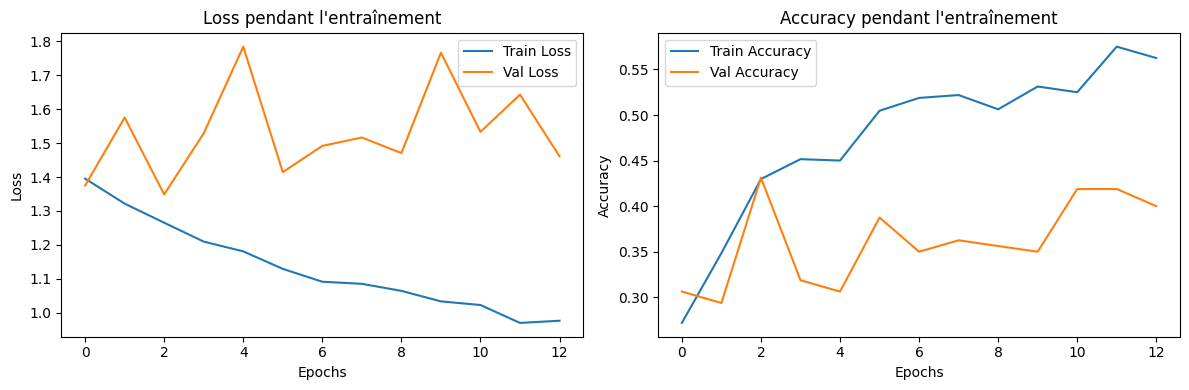


Évaluation du meilleur modèle...


1/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6562 - loss: 1.0200

3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5920 - loss: 1.1083

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5495 - loss: 1.1549

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5258 - loss: 1.1937

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.4313 - loss: 1.3488


Loss du meilleur modèle : 1.3488
Accuracy du meilleur modèle : 0.4313


In [13]:
# Préparation des données avec ImageDataGenerator
def prepare_image_data(image_dir, image_size, batch_size=32, validation_split=0.2):
    """
    Prépare les générateurs de données pour l'entraînement et la validation
    """
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        #width_shift_range=0.2,
        #height_shift_range=0.2,
        horizontal_flip=True,
        validation_split=validation_split
    )

    val_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=validation_split
    )

    train_generator = train_datagen.flow_from_directory(
        image_dir,
        target_size=image_size,
        batch_size=batch_size,
        class_mode='categorical',
        subset='training',
        shuffle=True,
        seed=42
    )

    validation_generator = val_datagen.flow_from_directory(
        image_dir,
        target_size=image_size,
        batch_size=batch_size,
        class_mode='categorical',
        subset='validation',
        shuffle=False,
        seed=42
    )

    return train_generator, validation_generator

# Préparation des données
batch_size = 32
train_gen, val_gen = prepare_image_data(image_dir, image_size, batch_size)

# Callbacks pour l'entraînement
def setup_callbacks(model_dir, model_name):
    """
    Configure les callbacks pour l'entraînement
    """
    model_path = os.path.join(model_dir, f"best_{model_name}.h5")

    checkpoint = ModelCheckpoint(
        model_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        mode='min',
        verbose=1
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    return [checkpoint, early_stop], model_path

# Configuration des callbacks
callbacks, best_model_path = setup_callbacks(model_dir, "image_classifier")

# Entraînement du modèle
def train_image_classifier(model, train_generator, validation_generator, callbacks, epochs=50):
    """
    Entraîne le modèle de classification d'images
    """
    history = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=validation_generator,
        callbacks=callbacks,
        verbose=1
    )

    return history

# Lancement de l'entraînement
print("Début de l'entraînement du classifieur d'images...")
history = train_image_classifier(
    image_classifier,
    train_gen,
    val_gen,
    callbacks,
    epochs=32
)

# Visualisation des résultats
def plot_training_history(history):
    """
    Affiche les courbes d'apprentissage
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Loss pendant l\'entraînement')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax2.set_title('Accuracy pendant l\'entraînement')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

# Charger le meilleur modèle sauvegardé
best_model = tf.keras.models.load_model(best_model_path)

# Évaluation du meilleur modèle
print("\nÉvaluation du meilleur modèle...")
val_loss, val_accuracy = best_model.evaluate(val_gen, verbose=1)

print(f"Loss du meilleur modèle : {val_loss:.4f}")
print(f"Accuracy du meilleur modèle : {val_accuracy:.4f}")




Génération de la matrice de confusion...


1/5 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step

3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step


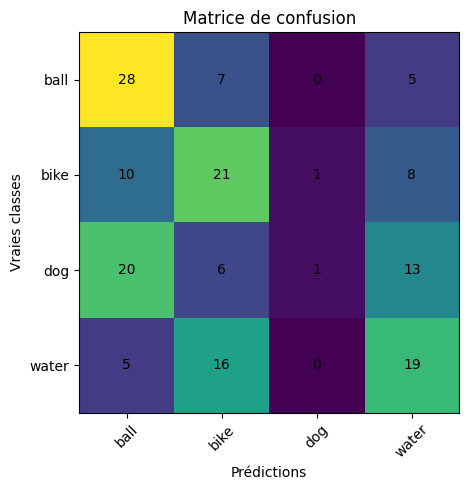

In [14]:
# Prédictions pour la matrice de confusion
print("\nGénération de la matrice de confusion...")
pred_probs = best_model.predict(val_gen, verbose=1)
pred_classes = np.argmax(pred_probs, axis=1)

true_classes = val_gen.classes
cm = tf.math.confusion_matrix(true_classes, pred_classes).numpy()

plt.figure(figsize=(5,5))
plt.imshow(cm)
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Prédictions")
plt.ylabel("Vraies classes")
plt.title("Matrice de confusion")

# Ajouter les nombres dans les cases
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


# Partie classification de textes

**Remarques :**
- Les textes sont dans le dossier `captions` et dans `captions.csv` (avec les labels).
- Pour utiliser SmallBERT (ou BERT) n'oubliez pas qu'il est indispensable de "tokenizer" vos phrases. Vous pouvez par exemple utiliser `TextVectorization` de Keras (voir [TextVectorization](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/)). Assurez-vous d'utiliser la même longueur `sequence_length` que celle attendue par SmallBERT. Regardez bien ce qu'il faut faire pour ajouter vos tokens au tokenizer.
- Comme vous allez apprendre le vocabulaire des mots qui sont dans `captions.csv` n'oubliez pas que par la suite vous en aurez besoin ... alors plutôt que de recommencer à chaque fois, pensez à le sauvegarder une fois pour toute. Pour accéder au vocabulaire appris, vous pouvez utiliser `.getvocabulary()` et simplement sauvegarder ce vocabulaire dans un fichier texte avec un mot par ligne comme par exemple `vocab.txt`.
- BERT et plus particulièrement SmallBERT n'est pas initialement fait pour faire de la classification. Il renvoie un tenseur séquence de forme `(batch, seq_len, embed_dim)`. Il va donc falloir le modifier un peu pour faire de la classification et donc lui ajouter un MLP comme classiquement. Ci-dessous quelques conseils pour vous aider à bien alimenter votre MLP.

Examinons un peu la sortie de SmallBERT. Considérons un batch composé des deux phrases suivantes :   
- *"a small red plane"*, après tokenization nous avons : Tokens (seq_len = 6) : [w1="a", w2="small", w3="red", w4="plane", PAD, PAD]"
- *"a big dog on the beach"*, après tokenization nous avons :
Tokens (seq_len = 6) : [w1="a", w2="big", w3="dog", w4="on", w5="the", w6="beach"]. Il n'y a pas de PAD car la séquence est pleine.   


A la sortie de SmallBERT nous avons un tenseur de la forme (batch=2, seq_len=6, embed_dim=3), i.e. sortie = (2, 6, 3). Pour simplifier nous prenons des embeddings de taille 3.   

Pour la première phrase (sortie[0, :, :]) la forme par phrase est (seq_len=6, embed_dim=3) donc 6 vecteurs de taille 3 :   
pos 0 ( "a" )      : [ 0.60, -0.20,  0.10 ]  
pos 1 ( "small" )  : [ 0.40,  0.30, -0.10 ]  
pos 2 ( "red" )    : [-0.20,  0.50,  0.20 ]  
pos 3 ( "plane" )  : [ 0.41, -0.12,  0.15 ]  
pos 4 ( PAD )      : [ 0.00,  0.00,  0.00 ]  
pos 5 ( PAD )      : [ 0.00,  0.00,  0.00 ]  

Pour la seconde phrase (sortie[1, :, :]) la forme par phrase est (seq_len=6, embed_dim=3) donc 6 vecteurs de taille 3 :  
pos 0 ( "a" )      : [ 0.20,  0.10, -0.30 ]  
pos 1 ( "big" )    : [ 0.00,  0.40,  0.20 ]  
pos 2 ( "dog" )    : [ 0.30, -0.20,  0.10 ]  
pos 3 ( "on" )     : [ 0.10,  0.00,  0.20 ]  
pos 4 ( "the" )    : [-0.20,  0.30,  0.00 ]  
pos 5 ( "beach" )  : [ -0.06,  0.18,  0.09 ]  

Ce que nous aimerions obtenir pour remplir notre classifier c'est une forme (batch, embed_dim). Donc récupérer un seul vecteur là où nous avons 6.

**Astuce :** N'oubliez pas que SmallBERT ne contient pas, contrairement à BERT, de token `CLS`. Celà veut dire que ce n'est pas le modèle qui va résumer mais c'est à vous de trouver la méthode "la moins pire". "Moins pire" car  `CLS` dans BERT est mis à jour dans les différentes couches du modèle et et que là vous n'avez à votre disposition que la dernière couche. Il existe plusieurs solutions pour le faire on peut considérer le premier mot, la moyenne de tous les mots, etc. Il faut trouver la plus appropriée. N'oubliez pas de bien tout relire ce que l'on vous donne ;)


In [15]:



# Nettoyage de la session
tf.keras.backend.clear_session()

# Chargement des données texte
captions_csv_path = os.path.join(dataset_dir, "captions.csv")
df = pd.read_csv(captions_csv_path)

print("Aperçu des données texte:")
print(df.head())
print(f"\nNombre total de textes: {len(df)}")
print(f"Distribution des classes:")
print(df['label'].value_counts())

# Préparation des données texte
texts = df['caption'].fillna("").astype(str).tolist()
labels = df['label'].astype(str).tolist()

# Encodage des labels
label_encoder = tf.keras.utils.to_categorical(
    [class_names.index(label) for label in labels], 
    num_classes=len(class_names)
)

# Split des données texte (80 train /20 test)
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, label_encoder, test_size=0.2, random_state=42, stratify=labels
)

# Split supplémentaire pour validation (20% des 80% train = 16% validation)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, train_labels, test_size=0.2, random_state=42, stratify=[class_names[np.argmax(l)] for l in train_labels]
)

print(f"\nSplit des données texte:")
print(f"Train: {len(train_texts)} textes")
print(f"Validation: {len(val_texts)} textes")
print(f"Test: {len(test_texts)} textes")

# Création du tokenizer avec TextVectorization
print("\nCréation du tokenizer...")
text_vectorizer = TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length,
    standardize='lower_and_strip_punctuation',
    split='whitespace'
)

# Adaptation du tokenizer sur l'ensemble d'entraînement
text_vectorizer.adapt(train_texts)

# Sauvegarde du vocabulaire
vocab = text_vectorizer.get_vocabulary()
vocab_path = os.path.join(model_dir, "vocab.txt")
with open(vocab_path, 'w', encoding='utf-8') as f:
    for word in vocab:
        f.write(word + '\n')
print(f"Vocabulaire sauvegardé ({len(vocab)} mots) dans: {vocab_path}")

# Construction du modèle de classification de texte avec SmallBERT
def build_text_classifier(vocab_size, sequence_length, num_classes, embed_dim=128):
    """
    Construit un modèle de classification de texte utilisant SmallBERT
    """
    # Entrée texte
    text_input = layers.Input(shape=(sequence_length,), dtype=tf.int32, name="text_input")
    
    # SmallBERT encoder
    small_bert = SmallBERT(
        sequence_length=sequence_length,
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        num_heads=num_heads,
        ff_dim=ff_dim,
        num_layers=num_layers
    )
    
    # Sortie de SmallBERT (batch, seq_len, embed_dim)
    bert_output = small_bert(text_input)
    
    # Stratégie de pooling - utilisation de MaskedMean pour gérer les PAD
    # Nous devons passer à la fois la sortie BERT et les tokens d'entrée
    pooled_output = MaskedMean()([bert_output, text_input])  # (batch, embed_dim)
    
    # Classificateur
    dropout1 = layers.Dropout(0.3)(pooled_output)
    dense1 = layers.Dense(256, activation='relu')(dropout1)
    dropout2 = layers.Dropout(0.2)(dense1)
    dense2 = layers.Dense(128, activation='relu')(dropout2)
    output = layers.Dense(num_classes, activation='softmax', name='text_output')(dense2)
    
    model = models.Model(inputs=text_input, outputs=output, name="text_classifier")
    return model

# Création du modèle
text_classifier = build_text_classifier(
    vocab_size=vocab_size,
    sequence_length=sequence_length,
    num_classes=len(class_names),
    embed_dim=embed_dim
)

# Compilation du modèle
text_classifier.compile(
    optimizer=Adam(learning_rate=0.0001),  # Learning rate plus petit pour BERT
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Affichage de l'architecture
text_classifier.summary()

Aperçu des données texte:
                 image_path label  \
0  images/bike/bike_001.jpg  bike   
1  images/bike/bike_002.jpg  bike   
2  images/bike/bike_004.jpg  bike   
3  images/bike/bike_005.jpg  bike   
4  images/bike/bike_006.jpg  bike   

                                             caption  
0  A young boy, likely around 6 years old, sits a...  
1  A lone cyclist pedaled uphill on their trusty ...  
2  A cyclist wearing a helmet pedals slowly acros...  
3  The lady pedaled her bike down the sidewalk, h...  
4  A man pedals his bicycle down a rugged, rocky ...  

Nombre total de textes: 800
Distribution des classes:
label
bike     200
ball     200
water    200
dog      200
Name: count, dtype: int64

Split des données texte:
Train: 512 textes
Validation: 128 textes
Test: 160 textes

Création du tokenizer...
Vocabulaire sauvegardé (3459 mots) dans: ./models_forclip/vocab.txt


Model: "text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ small_bert          │ (None, 32, 128)   │  1,944,832 │ text_input[0][0]  │
│ (SmallBERT)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_mean         │ (None, 128)       │          0 │ small_bert[0][0], │
│ (MaskedMean)        │                   │            │ text_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ masked_mean[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     33,024 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_output (Dense) │ (None, 4)         │        516 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,011,268 (7.67 MB)

 Trainable params: 2,011,268 (7.67 MB)

 Non-trainable params: 0 (0.00 B)

Début de l'entraînement du classifieur de texte...
Epoch 1/50


 1/16 ━━━━━━━━━━━━━━━━━━━━ 25:52 104s/step - accuracy: 0.3438 - loss: 1.4792


Epoch 1: val_loss improved from None to 1.36249, saving model to ./models_forclip/best_text_classifier.h5


16/16 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.2891 - loss: 1.3943 - val_accuracy: 0.2891 - val_loss: 1.3625


Epoch 2/50


...

 1/16 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 1.0000 - loss: 0.0029


Epoch 25: val_loss did not improve from 0.51495


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0049 - val_accuracy: 0.7891 - val_loss: 0.8033


Epoch 25: early stopping


Restoring model weights from the end of the best epoch: 10.


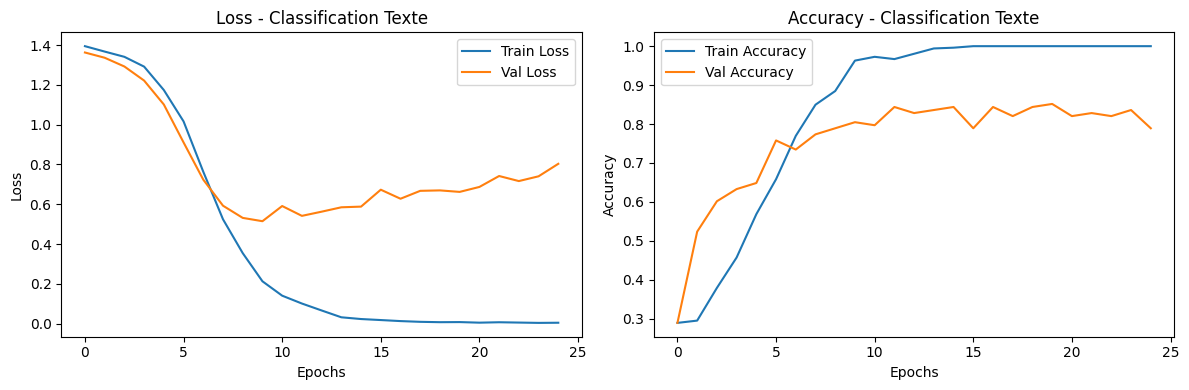


Évaluation du meilleur modèle de texte sur la validation...


1/4 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.8438 - loss: 0.4156

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8047 - loss: 0.5149


Loss de validation (texte): 0.5149
Accuracy de validation (texte): 0.8047

Évaluation du meilleur modèle de texte sur le test...
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7188 - loss: 0.7358

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7563 - loss: 0.5905


Loss de test (texte): 0.5905
Accuracy de test (texte): 0.7563

Génération de la matrice de confusion pour le texte...


1/5 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


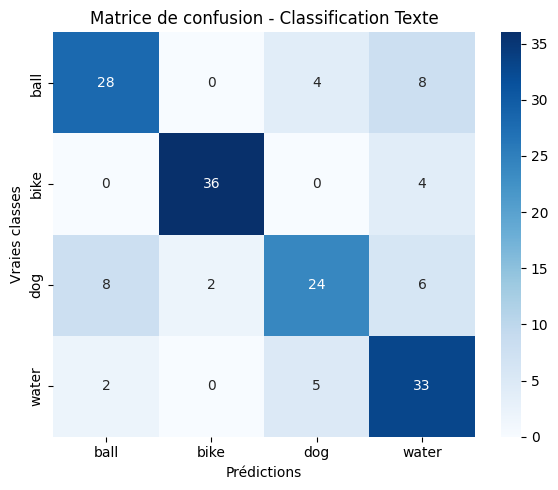


Rapport de classification:
              precision    recall  f1-score   support

        ball       0.74      0.70      0.72        40
        bike       0.95      0.90      0.92        40
         dog       0.73      0.60      0.66        40
       water       0.65      0.82      0.73        40

    accuracy                           0.76       160
   macro avg       0.76      0.76      0.76       160
weighted avg       0.76      0.76      0.76       160


Test de prédiction sur quelques exemples:


Texte: A playful golden retriever runs joyfully across the lush gre...
  Vrai: dog, Prédit: dog
  Confiance: 0.7395

Texte: A determined cyclist, dressed in racing gear, pedals his sle...
  Vrai: bike, Prédit: bike
  Confiance: 0.9964



Texte: The sun casts a warm glow over the public skate and bike par...
  Vrai: bike, Prédit: bike
  Confiance: 0.9805

Texte: "A serene lake on a warm summer day, surrounded by lush gree...
  Vrai: water, Prédit: dog
  Confiance: 0.6283



Texte: A young boy frolics in the snow, his bright yellow and black...
  Vrai: dog, Prédit: ball
  Confiance: 0.6546

Exemple de prédiction:
Texte: 'a beautiful dog running in the water'
Classe prédite: water (confiance: 0.9987)
Probabilités pour toutes les classes:
  ball: 0.0006
  bike: 0.0005
  dog: 0.0002
  water: 0.9987


In [16]:

# Préparation des données pour l'entraînement
def prepare_text_data(texts, labels, batch_size=32, shuffle=True):
    """
    Prépare un dataset TensorFlow pour l'entraînement texte
    """
    # Tokenization des textes
    tokenized_texts = text_vectorizer(texts).numpy()
    
    # Création du dataset
    dataset = tf.data.Dataset.from_tensor_slices((tokenized_texts, labels))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(texts))
    
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

# Préparation des datasets
batch_size = 32
train_text_dataset = prepare_text_data(train_texts, train_labels, batch_size, shuffle=True)
val_text_dataset = prepare_text_data(val_texts, val_labels, batch_size, shuffle=False)
test_text_dataset = prepare_text_data(test_texts, test_labels, batch_size, shuffle=False)

# Callbacks pour l'entraînement texte
def setup_text_callbacks(model_dir, model_name):
    """
    Configure les callbacks pour l'entraînement texte
    """
    model_path = os.path.join(model_dir, f"best_{model_name}.h5")
    
    checkpoint = ModelCheckpoint(
        model_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        mode='min',
        verbose=1
    )
    
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=15,  # Plus de patience pour BERT
        restore_best_weights=True,
        verbose=1
    )
    
    return [checkpoint, early_stop], model_path

# Configuration des callbacks
text_callbacks, best_text_model_path = setup_text_callbacks(model_dir, "text_classifier")

# Entraînement du modèle texte
print("Début de l'entraînement du classifieur de texte...")
text_history = text_classifier.fit(
    train_text_dataset,
    epochs=50,
    validation_data=val_text_dataset,
    callbacks=text_callbacks,
    verbose=1
)

# Visualisation des résultats
def plot_text_training_history(history):
    """
    Affiche les courbes d'apprentissage pour le texte
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Courbe de loss
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Loss - Classification Texte')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    # Courbe d'accuracy
    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax2.set_title('Accuracy - Classification Texte')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_text_training_history(text_history)

# Chargement du meilleur modèle sauvegardé
best_text_model = tf.keras.models.load_model(
    best_text_model_path,
    custom_objects={
        'SmallBERT': SmallBERT,
        'PositionalEmbedding': PositionalEmbedding,
        'TransformerBlock': TransformerBlock,
        'MaskedMean': MaskedMean,
        'SelectFirstToken': SelectFirstToken,
        'SelectMean': SelectMean,
        'L2Normalize': L2Normalize
    }
)

# Évaluation sur l'ensemble de validation
print("\nÉvaluation du meilleur modèle de texte sur la validation...")
val_text_loss, val_text_accuracy = best_text_model.evaluate(val_text_dataset, verbose=1)
print(f"Loss de validation (texte): {val_text_loss:.4f}")
print(f"Accuracy de validation (texte): {val_text_accuracy:.4f}")

# Évaluation sur l'ensemble de test
print("\nÉvaluation du meilleur modèle de texte sur le test...")
test_text_loss, test_text_accuracy = best_text_model.evaluate(test_text_dataset, verbose=1)
print(f"Loss de test (texte): {test_text_loss:.4f}")
print(f"Accuracy de test (texte): {test_text_accuracy:.4f}")

# Matrice de confusion pour le texte
print("\nGénération de la matrice de confusion pour le texte...")
test_predictions = best_text_model.predict(test_text_dataset)
test_pred_classes = np.argmax(test_predictions, axis=1)
test_true_classes = np.argmax(test_labels, axis=1)


from sklearn.metrics import classification_report
import seaborn as sns

cm = confusion_matrix(test_true_classes, test_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prédictions')
plt.ylabel('Vraies classes')
plt.title('Matrice de confusion - Classification Texte')
plt.tight_layout()
plt.show()

print("\nRapport de classification:")
print(classification_report(test_true_classes, test_pred_classes, 
                          target_names=class_names))


print("\nTest de prédiction sur quelques exemples:")
sample_texts = test_texts[:5]
sample_true_labels = [class_names[idx] for idx in test_true_classes[:5]]

for i, text in enumerate(sample_texts):
    # Tokenization
    tokens = text_vectorizer([text])
    # Prédiction
    prediction = best_text_model.predict(tokens, verbose=0)
    pred_class = class_names[np.argmax(prediction)]
    true_class = sample_true_labels[i]
    
    print(f"Texte: {text[:60]}...")
    print(f"  Vrai: {true_class}, Prédit: {pred_class}")
    print(f"  Confiance: {np.max(prediction):.4f}")
    print()

# Fonction utilitaire pour faire des prédictions sur de nouveaux textes
def predict_text_class(model, text_vectorizer, text, class_names):
    """
    Prédit la classe d'un texte
    """
    tokens = text_vectorizer([text])
    prediction = model.predict(tokens, verbose=0)
    pred_class_idx = np.argmax(prediction)
    confidence = np.max(prediction)
    
    return class_names[pred_class_idx], confidence, prediction[0]

# Exemple d'utilisation
test_text = "a beautiful dog running in the water"
pred_class, confidence, all_probs = predict_text_class(best_text_model, text_vectorizer, test_text, class_names)
print(f"Exemple de prédiction:")
print(f"Texte: '{test_text}'")
print(f"Classe prédite: {pred_class} (confiance: {confidence:.4f})")
print(f"Probabilités pour toutes les classes:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}: {all_probs[i]:.4f}")

# Partie CLIP

## Construction du modèle

**Remarques :**
- Il est très important pour réaliser cette partie de bien avoir compris le principe des autoencodeurs/variational autoencodeurs et de l'espace latent. Il est impératif de bien lire les guides notamment ceux sur les images.
- Précédemment nous avons fait deux classifieurs : l'un pour l'image et l'autre pour le texte. En fait le code réalisé est presque similaire. Par contre ici nous n'avons plus besoin de classer donc la dernière couche n'est plus nécessaire pour réaliser les encodeurs images et textes.
- CLIP est un modèle composé d'une partie encodeur image et d'une partie encodeur texte. L'objectif est que les espaces latents soient associés comme l'illustre la Figure suivante.
- Vous constaterez que pour le CLIP on a une matrice carré formée à partir de la partie encodeur de l'image et de la partie encodeur du texte. Cela veut dire que la partie image et texte doivent être projetés de la même manière. En d'autres termes, les embeddings pour l'image et pour le texte doivent avoir la même taille à la sortie.


<center>
    <img src="https://www.lirmm.fr/~poncelet/Ressources/architectureCLIP.png" width="480" height="400">
    <p>Le principe du fonctionnement d'un CLIP (source : https://viso.ai/deep-learning/clip-machine-learning/)</p>
</center>

**Attention :** CLIP maximise la similarité cosinus entre paires (image, texte) positives et la minimise pour les négatives. Il est donc impératif d'avoir la même échelle pour tous : il faut ramener chaque embedding sur une norme 1. Ainsi, on compare les directions (le contenu) et pas la taille du vecteur.  

**Astuce :** voir [L2-Normalization](https://www.geeksforgeeks.org/machine-learning/python-tensorflow-math-l2_normalize/) et surtout bien lire les ressouces disponibles !!! En autres termes après avoir projeté les embeddings en sortie il faut les normaliser ... et c'est comme ça qu'on finalise les encodeurs.

Maintenant il faut penser au modèle pour le CLIP.   

**Astuce :** se poser les bonnes questions :    
- combien d'entrées pour le modèle ?
- combien de sorties le clip va traîter ?
Réfléchissez bien et essayer de bien voir pour chaque composante ses entrées et ses sorties. N'hésitez pas à faire un résumé de la structure de vos encodeurs pour vérifier que tout est cohérent.   
Par exemple pour l'encodeur d'image nous savons que la structure d'entrée doit être : (B, H, W, C) où B est le batchsize, H la hauteur de l'image, W la largeur de l'image et C le nombre de canaux. Par contre la sortie du décodeur ,si vous avez bien tenu compte des remarques précédentes, doit être : (B, D) avec B le batchsize et D la dimension de l'embedding de l'image. Idem pour l'encodeur de texte en entrée nous avons (B, L) où B est la batchsize et L la longueur de la phrase (i.e. le nombre de tokens). La sortie doit être (B,D) où B est le batchsize et D la dimension de l'embedding du texte.

Par exemple dans notre cas pour vous faire une idée de la valeur attendu nous pourrions avoir : H=224, W=224, C=3 et D=128. Avec bien sûr D similaire pour les deux encodeurs.    

Si vous avez bien compris, cela veut dire que pour votre modèle CLIP vous avez comme entrée : Images : (B, H, W, C) - Textes (token ids) : (B, L) et vous avez comme sortie Embeddings image : (B, D) (normalisés) - Embeddings texte : (B, D) (normalisés).



## A propos de la loss

Il faut maintenant trouver une loss. Pour un modèle CLIP on utilise une *loss_contrastive*. Le principe est d'apprendre des représentations en rapprochant les paires qui vont ensemble (positives) et en éloignant celles qui ne vont pas ensemble (négatives). L'intuition est la suivante : On prend un batch de couples correspondants (ex. image i - texte i), on calcule les similarités entre toutes les images et tous les textes du batch (matrice BxB). La diagonale contient les paires positives (i avec i) et le reste les paires négatives (i avec j différent de i). L'objectif de la loss pousse la diagonale vers le haut (similitude élevée) et le reste vers le bas.   

Pour vous faciliter la vie, nous vous fournissons la loss sous la forme d'une classe pour facilement l'intégrer à votre modèle. Elle est inspirée de l'article [CLIP](https://arxiv.org/pdf/2103.00020). Le principe général est le suivant (c'est ce qui se fait dans la méthode `call` de la classe : on va rapprocher les embeddings d'images et de textes qui vont ensemble et éloigner ceux qui ne correspondent pas. En entrée elle va prendre image_embeds ((B, D) — vecteurs image L2-normalisés), text_embeds ((B, D) — vecteurs texte L2-normalisés) et
temperature (τ) pour règler “l'exigence” du softmax (en gros plus c'est petit plus c'est strict) (voir les guides). pour chaque image du batch, on lui présente tous les textes du batch (B candidats) et on lui demande d'identifier le bon (son texte associé). On fait aussi l'inverse (chaque texte doit retrouver son image). On calcule donc les similarités :    
$$  
logits=\frac{image\_embeds\ x\ text\_embeds^T}{τ}
$$
La case (i, j) correspond à la similarité entre image i et texte j.  

Les étiquettes sont utilisées car on veut que l'image i choisisse le texte i (les bonnes réponses sont sur la diagonale). D'où en gros labels = [0, 1, 2, ..., B-1].   

Enfin on veut que la perte soit symétrique pour l'image et le texte :    
- image vers texte : chaque ligne de logits passe dans une cross-entropy pour forcer le bon texte (diagonale) - `loss_i = tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)`
- texte vers image : on refait la même chose sur $logits^T$ - `loss_t = tf.keras.losses.sparse_categorical_crossentropy(labels, tf.transpose(logits), from_logits=True)`.  

Ensuite on moyenne les deux pertes : `tf.reduce_mean(loss_i + loss_t) / 2
`   

Au final on obtient un scalaire (qui correspond à la moyenne des deux puis bien sûr la moyenne sur le batch)

La Figure suivante illustre un exemple de matrice et de rapprochement.


<center>
    <img src="https://www.lirmm.fr/~poncelet/Ressources/exemplematriceclip.png" width="600" height="500">
    <p>Un exemple de matrice (source : https://openai.com/index/clip/)</p>
</center>

In [17]:
# NETTOYAGE COMPLET DE LA SESSION
print("Nettoyage complet de la session TensorFlow...")
tf.keras.backend.clear_session()
import gc
gc.collect()

Nettoyage complet de la session TensorFlow...


0

# La première cellule crêe la matrice de perte entre les images et le texte. Cette cellule était déjà fournie dans le notebook par les profs.

In [18]:
# Perte contrastive CLIP
# Le but de cette fonction est d’aligner les embeddings d’images et de textes
# correspondants dans un espace latent partgé. Elle est inspirée du papier
# CLIP, où l'on entraîne le modèle à prédire quelle image correspond à quel
# texte et réciproquement.

@register_keras_serializable(package="clip")
class ClipLossLayer(layers.Layer):
    def __init__(self, temperature=0.07, **kwargs):
        super().__init__(**kwargs)
        self.temperature = temperature
        self.clip_loss_metric = tf.keras.metrics.Mean(name="clip_loss")

    def call(self, inputs):
        # l'inputs est forcément (img, txt) ou [img, txt]
        img, txt = inputs  # (B, D) attention il faut avoir L2-normalisés !!

        # Matrice des similarités (cosinus parce qu'on a L2 zt ça simplifie)
        logits = tf.matmul(img, txt, transpose_b=True) / self.temperature

        # Les Labels implicites : c'est la diagonale
        labels = tf.range(tf.shape(logits)[0])

        li = tf.keras.losses.sparse_categorical_crossentropy(labels,
                                                             logits,
                                                             from_logits=True)
        lt = tf.keras.losses.sparse_categorical_crossentropy(labels,
                                                          tf.transpose(logits),
                                                          from_logits=True)
        loss = tf.reduce_mean(li + lt) / 2.0

        # Ca c'est super important car on ajoute la loss au graphe
        # du modèle et ça nous simplifie la vie
        # après on met à jour la métrique interne si on veut la suivre
        self.add_loss(loss)
        self.clip_loss_metric.update_state(loss)

        # On retourne un TUPLE de tenseurs(surtout pas une liste)
        # dc facileà récupérer
        return (img, txt)

    def get_config(self):
        return {**super().get_config(), "temperature": self.temperature}


Maintenant vous avez la loss à votre disposition. Si vous regardez bien elle prend en entrée un embedding d'image et un embedding de texte (`img, txt = inputs`), elle applique ce qu'on a expliqué au-dessus et au final retourne un embedding d'image et de texte (`return (img, txt)`). Elle est donc comme n'importe quelle fonction de loss.  

Maintenant le problème est comment prendre en compte cette fonction de loss ? N'oubliez pas le nombre de sorties de votre modèle. Dans Keras, si on passe une seule loss (par exemple dans `compile`), elle est appliquée séparément à chaque sortie. Ici notre loss a besoin des deux en même temps !!! En fait, il existe une solution simple : pourquoi ne pas insérer directement la loss dans la définition du modèle ??   

Ca peut sembler bizarre non ? en fait si on réfléchit bien la loss est généralement mise à la suite du modèle. C'est ce qu'on fait quand on fait par exemple : `compile(loss="binary_crossentropy")`. En fait, le rôle de `compile` est de fixer généralement l'optimiseur et la loss. Quand on n'a qu'une seule sortie, pas de problème : la loss passée dans `compile` s'applique à la sortie et tout fonctionne comme attendu. Par contre là, on a 2 sorties !! Quand un modèle a plusieurs sorties, la loss passée dans `compile` est calculée séparément pour chaque sortie, puis Keras les additionne/pondère. Donc, `compile(loss=...)` ne sait pas considérer deux sorties en même temps ! En d'autres termes, quand un modèle a deux sorties, `compile(loss=...)` applique la loss à chaque sortie comme si elle était seule, puis additionne les deux valeurs. Pour une loss contrastive, c'est un vrai problème car elle doit comparer en même temps l'embedding image et l'embedding texte.  
L'idée est donc de mettre la loss dans le modèle à l'endroit où les deux embeddings sont disponibles : une petite couche calcule la loss contrastive puis l'ajoute avec `add_loss(...)` (si vous avez fait attention, vous avez noté cet `add_loss` dans la classe `ClipLossLayer`). Après, on peut compiler normalement. On pourrait même ajouter une autre loss si on en avait besoin mais dans notre cas c'est inutile, donc on pourra avoir un `compile` sans loss car elle est déjà introduite dans le modèle.     


En gros, il suffit  d'ajouter cette "petite couche" qui vous est donnée. Elle prend en entrée (img_emb, txt_emb), calcule la loss contrastive, l'attache avec add_loss(...) et ajoute même un  `add_metric(...)` qui permet d'afficher les "metrics" lors de l'apprentissage. Cette couche retourne en sortie les deux embeddings de texte et d'image `(img, txt)`.

# Cette cellule sert è nettoyer les deux modèles (texte et images) qu’on a déjà généré.

In [19]:
def build_clip_encoders():
    """Construit les encodeurs CLIP en injectant les poids entraînés"""
    
    # 1. Charger les modèles de base
    custom_objs = {
        'SmallBERT': SmallBERT,
        'PositionalEmbedding': PositionalEmbedding,
        'TransformerBlock': TransformerBlock,
        'MaskedMean': MaskedMean
    }
    
    image_base = tf.keras.models.load_model(os.path.join(model_dir, "best_image_classifier.h5"))
    text_base = tf.keras.models.load_model(os.path.join(model_dir, "best_text_classifier.h5"), custom_objects=custom_objs)
    
    # --- Encodeur d'images CLIP (Approche Séquentielle) ---
    img_input = layers.Input(shape=(224, 224, 3), name="image_input_clip")
    
    # Le modèle image est Séquentiel, on itère simplement sur les couches
    # en évitant InputLayer et en s'arrêtant avant la tête de classification (-2)
    x_img = img_input
    for layer in image_base.layers[:-2]:
        if isinstance(layer, layers.InputLayer):
            continue
        x_img = layer(x_img)
        
    image_projection = layers.Dense(embed_dim, activation=None, name="image_projection")(x_img)
    image_embedding = L2Normalize()(image_projection)
    
    image_encoder_clip = tf.keras.Model(inputs=img_input, outputs=image_embedding, name="image_encoder")
    
    # --- Encodeur de texte CLIP (Approche Fonctionnelle) ---
    txt_input = layers.Input(shape=(sequence_length,), dtype=tf.int32, name="text_input_clip")
    
    # Le modèle texte est Fonctionnel (connexions complexes vers MaskedMean).
    # On DOIT utiliser l'extraction de graphe.
    # .input est accessible sur les modèles fonctionnels.
    text_backbone = tf.keras.Model(inputs=text_base.input, outputs=text_base.layers[-2].output)
    
    # On appelle ce sous-modèle avec notre nouvelle entrée
    x_txt = text_backbone(txt_input)
    
    text_projection = layers.Dense(embed_dim, activation=None, name="text_projection")(x_txt)
    text_embedding = L2Normalize()(text_projection)
    
    text_encoder_clip = tf.keras.Model(inputs=txt_input, outputs=text_embedding, name="text_encoder")
    
    return image_encoder_clip, text_encoder_clip

# Construire les encodeurs
image_encoder, text_encoder = build_clip_encoders()

# Afficher les architectures
print("Encodeur d'images:")
image_encoder.summary()

print("\nEncodeur de texte:")
text_encoder.summary()

Encodeur d'images:


Model: "image_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input_clip (InputLayer)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image_projection (Dense)        │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalize (L2Normalize)      │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,744,192 (37.17 MB)

 Trainable params: 9,744,192 (37.17 MB)

...

Model: "text_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_input_clip (InputLayer)    │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_15 (Functional)      │ (None, 128)            │     2,010,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_projection (Dense)         │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalize_1 (L2Normalize)    │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,027,264 (7.73 MB)

 Trainable params: 2,027,264 (7.73 MB)

 Non-trainable params: 0 (0.00 B)

# Les deux cellules suivantes mettent l’encodeur du texte et l’endoceur d’image dans le même modèle

In [20]:
def build_clip_model(image_encoder, text_encoder):
    """Construit le modèle CLIP complet"""
    
    # Entrées
    image_input = image_encoder.input
    text_input = text_encoder.input
    
    # Encodage
    image_embedding = image_encoder(image_input)
    text_embedding = text_encoder(text_input)
    
    # Couche de loss contrastive
    image_embedding, text_embedding = ClipLossLayer(temperature=0.07)([image_embedding, text_embedding])
    
    # Modèle final
    clip_model = tf.keras.Model(
        inputs=[image_input, text_input],
        outputs=[image_embedding, text_embedding],
        name="clip_model"
    )
    
    return clip_model

# Construction du modèle CLIP
clip_model = build_clip_model(image_encoder, text_encoder)
clip_model.summary()

Model: "clip_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input_clip    │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input_clip     │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_encoder       │ (None, 128)       │  9,744,192 │ image_input_clip… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_encoder        │ (None, 128)       │  2,027,264 │ text_input_clip[… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clip_loss_layer     │ [(None, 128),     │          0 │ image_encoder[0]… │
│ (ClipLossLayer)     │ (None, 128)]      │            │ text_encoder[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,771,456 (44.90 MB)

 Trainable params: 11,771,456 (44.90 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Compilation du modèle (sans loss car elle est déjà dans le modèle)
clip_model.compile(
    optimizer=Adam(learning_rate=0.0001)
)

# Les trois cellules suivantes créen les tokens.

In [22]:
# Vérification et préparation du text_vectorizer pour CLIP
print("Vérification du text_vectorizer...")

# Si text_vectorizer n'existe pas, le recréer
if 'text_vectorizer' not in locals() and 'text_vectorizer' not in globals():
    print("Création du text_vectorizer...")
    
    # Lecture des données
    captions_csv_path = os.path.join(dataset_dir, "captions.csv")
    df = pd.read_csv(captions_csv_path)
    texts = df['caption'].fillna("").astype(str).tolist()
    
    # Création du tokenizer
    text_vectorizer = TextVectorization(
        max_tokens=vocab_size,
        output_mode="int",
        output_sequence_length=sequence_length,
        standardize='lower_and_strip_punctuation',
        split='whitespace'
    )
    
    # Adaptation sur tous les textes
    text_vectorizer.adapt(texts)
    print(f"Text_vectorizer créé avec {len(text_vectorizer.get_vocabulary())} tokens")
else:
    print("Text_vectorizer déjà existant")

Vérification du text_vectorizer...
Text_vectorizer déjà existant


# A propos du jeu de données d'apprentissage



**Remarque :**
- Chaque image doit correspondre à son texte.  
- N'oubliez pas, il y a deux entrées à notre modèle : des images et des textes.Vos batchs doivent donc contenir les deux. Avec comme format respectif pour les Images : (B, H, W, C) et pour les textes (token ids) : (B, L).
- Le format des textes est lié au fait qu'ils doivent être tokénisés avant.  
- Pour vous aider et ne pas perdre de temps à constituer vos batches pour regrouper les images et les textes nous vous donnons la fonction suivante. Le début de la fonction est relativement simple : on récupère les bons champs dans le fichier `captions.csv` puis on va rechercher les répertoires des images. Ensuite on a une fonction interne donc le rôle est de sélectionner un exemple : elle normalise l'image entre 0 et 1, force à ce que les images aient la même taille ici 224x224x3 et retourne à la fois l'image et le texte sous la forme de tokens.   
Le reste de la fonction est plus pour optimiser la création des batchs : on applique  `map(load_sample, num_parallel_calls=AUTOTUNE)` qui permet d'appeler la fonction et `AUTOTUNE` précise que ces opérations se font en parallèle pour gagner du temps. `ds.cache()` sert à mémoriser les exemples déjà prétraités (en RAM) et les epochs suivantes peuvent les utiliser directement sans refaire une génération. Enfin `batch(batch_size, drop_remainder=drop_remainder)` force à avoir des batches de taille fixe (notez que par défaut `drop_remainder=True`). N'oubliez pas que lorsqu'on utilise des batchs parfois le dernier n'a pas la même taille que les autres. Par exemple avec 1 003 paires image-texte et un batch_size=64, on aurait 15x64 = 960 batches pleins et un dernier lot de 43. Il ne faut pas oublier que dans un clip, chaque batch sert à construire une matrice de similarité BxB où B est la taille du batch. Donc le dernier lot poserait problème car la taille de B serait différente.

In [23]:
captions_csv_path = os.path.join(dataset_dir, "captions.csv")
def make_clip_dataset_smallbert(
    captions_csv_path,
    tokenizer_layer,
    batch_size=32,
    shuffle=True,
    drop_remainder=True,
    cache=True,
    seed=42,
):
    """
    Construit un tf.data.Dataset avec en sortie (images, token_ids) pour CLIP.
    """
    # On récupère le fichier captions.csv qui a tout
    df = pd.read_csv(captions_csv_path)
    image_paths = df["image_path"].astype(str).tolist()
    captions    = df["caption"].fillna("").astype(str).tolist()

    # Récupération du répertoire des images
    root = Path(dataset_dir)
    full_paths = [str(root / p) for p in image_paths]

    # Création du dataset d'image
    ds = tf.data.Dataset.from_tensor_slices((full_paths, captions))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(full_paths), seed=seed,
                        reshuffle_each_iteration=True)

    # Chargement d'une ensemble d'images normalisées et de tokens (le texte)
    IMAGE_H, IMAGE_W = 224, 224  # même que image_size

    def load_sample(img_path, caption):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [224, 224])
        img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
        tokens = tf.cast(tokenizer_layer(caption), tf.int32)  # (L,)
        # x = dict des 2 entrées, pour forcer à ne pas avoir de  y
        #return {"image_input": img, "text_input": tokens}
        return {"conv2d_20_input": img, "text_input": tokens}
        

    # Pour utiliser le cache et pouvoir faire les traitements en //
    ds = ds.map(load_sample, num_parallel_calls=AUTOTUNE)
    if cache:
        ds = ds.cache()
    # si drop_remainder=True on vire le dernier batch
    # s'il n'est pas de la bonne taille
    ds = ds.batch(batch_size, drop_remainder=drop_remainder).prefetch(AUTOTUNE)
    return ds

# Quanq le tokenizer est initialisé, un exemple d'appel que vous pourrez faire :
#train_dataset = make_clip_dataset_smallbert(captions_csv_path,
#                                               text_vectorizer,
#                                               batch_size=64)

**Conseil :** vérifiez toujours les `shape` en entrée et en sortie. C'est souvent une source d'erreur. Par exemple, quand vous aurez défini votre tokenizer, la cellule suivante vous permet de bien vérifier ce que vous allez passer à votre modèle. Avec un batchsize de 64, vous devriez obtenir quelque chose comme : (64, 224, 224, 3)  (64, L) où L est la longueur de la séquence (i.e. `sequence_length`).

In [24]:
# CELLULE 2 - Création des datasets (DÉCOMMENTER ET EXÉCUTER)
print("Recréation des datasets avec les bonnes clés...")
train_dataset = make_clip_dataset_smallbert(
    captions_csv_path,
    text_vectorizer,
    batch_size=64,
    shuffle=True
)

val_dataset = make_clip_dataset_smallbert(
    captions_csv_path,
    text_vectorizer,
    batch_size=64,
    shuffle=False
)

# Vérification
sample_batch = next(iter(train_dataset))
print("Clés du batch:", list(sample_batch.keys()))
print(f"Shape des images: {sample_batch['conv2d_20_input'].shape}")
print(f"Shape des textes: {sample_batch['text_input'].shape}")

Recréation des datasets avec les bonnes clés...


Clés du batch: ['conv2d_20_input', 'text_input']
Shape des images: (64, 224, 224, 3)
Shape des textes: (64, 32)


In [25]:
# A exécuter uniquement si text_tokenizer est initialisé.
#train_ds = make_clip_dataset_smallbert(captions_csv_path, text_vectorizer, batch_size=64)
#imgs, toks = next(iter(train_ds))
#print(imgs.shape, toks.shape)

# Les 4 cellules suivantes servent à Entraîner et à sauvegarder el modèle.

In [26]:
def setup_clip_callbacks(model_dir, model_name):
    """Configure les callbacks pour l'entraînement CLIP - VERSION CORRIGÉE"""
    model_path = os.path.join(model_dir, f"best_{model_name}.h5")
    
    checkpoint = ModelCheckpoint(
        model_path,
        monitor='clip_loss', 
        save_best_only=True,
        save_weights_only=False,
        mode='min',
        verbose=1
    )
    
    early_stop = EarlyStopping(
        monitor='clip_loss', 
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
    
    return [checkpoint, early_stop], model_path
clip_callbacks, best_clip_model_path = setup_clip_callbacks(model_dir, "clip_model")

In [27]:
# TEST avec 1 BATCH SEULEMENT d'abord ###pas encore 
print("TEST avec 1 batch seulement...")

# Prendre juste un batch pour tester
test_batch = next(iter(train_dataset))

# Vérifier que les prédictions fonctionnent
try:
    test_output = clip_model(test_batch, training=False)
    print("Prédiction réussie.")
    print(f"Output image shape: {test_output[0].shape}")
    print(f"Output text shape: {test_output[1].shape}")
except Exception as e:
    print(f" Erreur: {e}")

TEST avec 1 batch seulement...


 Erreur: Missing data for input "image_input_clip". You passed a data dictionary with keys ['conv2d_20_input', 'text_input']. Expected the following keys: ['image_input_clip', 'text_input_clip']


In [28]:
print("Début de l'entraînement du modèle CLIP...")

# --- 1. ADAPTATION DES DONNÉES (Indispensable pour nbconvert) ---
def align_clip_inputs(inputs, labels=None):
    """Renomme les clés pour correspondre au modèle CLIP"""
    vals = list(inputs.values())
    img = None
    txt = None
    
    # Détection automatique : Image (rank >= 3) vs Texte (rank < 3)
    for v in vals:
        if len(v.shape) >= 3:
            img = v
        else:
            txt = v
            
    new_inputs = {
        "image_input_clip": img,
        "text_input_clip": txt
    }
    
    if labels is not None:
        return new_inputs, labels
    return new_inputs

# On applique la transformation
print("Adaptation des datasets aux nouvelles entrées...")
train_dataset_mapped = train_dataset.map(align_clip_inputs)
val_dataset_mapped = val_dataset.map(align_clip_inputs)


# --- 2. CONFIGURATION DES CALLBACKS (Avec mode='min') ---
print("Configuration des callbacks...")
clip_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_clip_loss',
        patience=5,
        restore_best_weights=True,
        mode='min',  # Important
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(model_dir, "best_clip_model.h5"),
        monitor='val_clip_loss',
        save_best_only=True,
        mode='min',  # Important
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_clip_loss',
        factor=0.5,
        patience=2,
        mode='min',  # Important
        verbose=1
    )
]

# --- 3. ENTRAÎNEMENT ---
print("Lancement du .fit()...")
clip_history = clip_model.fit(
    train_dataset_mapped,       # On utilise bien la version mappée
    epochs=50,
    validation_data=val_dataset_mapped,
    callbacks=clip_callbacks,
    verbose=1
)

Début de l'entraînement du modèle CLIP...
Adaptation des datasets aux nouvelles entrées...
Configuration des callbacks...
Lancement du .fit()...
Epoch 1/50


 1/12 ━━━━━━━━━━━━━━━━━━━━ 30:13 165s/step - clip_loss: 4.4321 - loss: 4.4321

 3/12 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - clip_loss: 4.3829 - loss: 4.3829  

 4/12 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - clip_loss: 4.3590 - loss: 4.3590

 5/12 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step - clip_loss: 4.3384 - loss: 4.3384

...

 5/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - clip_loss: 1.5147 - loss: 1.5147

 9/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - clip_loss: 1.5030 - loss: 1.5030


Epoch 50: val_clip_loss improved from 2.01883 to 2.00600, saving model to ./models_forclip/best_clip_model.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 531ms/step - clip_loss: 1.4790 - loss: 1.4790 - val_clip_loss: 2.0060 - val_loss: 2.0060 - learning_rate: 2.5000e-05


Restoring model weights from the end of the best epoch: 50.


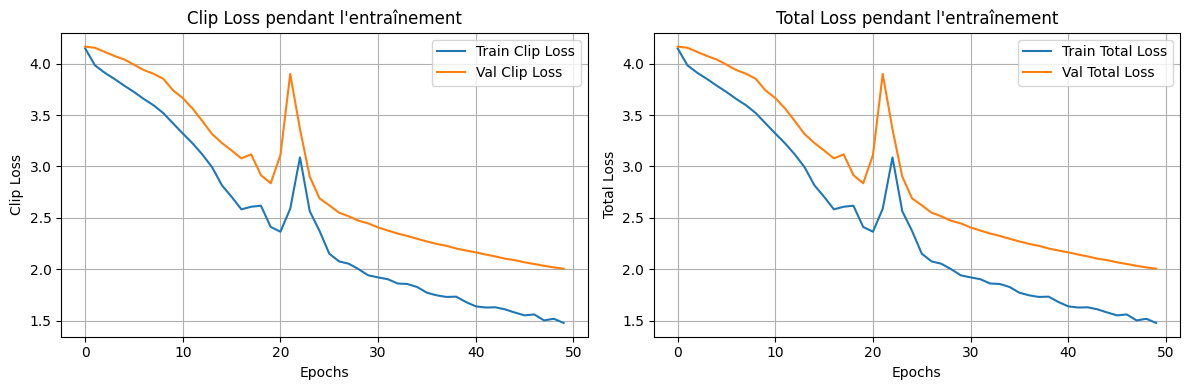

In [29]:
# VISUALISATION DES RÉSULTATS
def plot_clip_training(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Courbe de la loss CLIP
    ax1.plot(history.history['clip_loss'], label='Train Clip Loss')
    ax1.plot(history.history['val_clip_loss'], label='Val Clip Loss')
    ax1.set_title('Clip Loss pendant l\'entraînement')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Clip Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Courbe de la loss totale
    ax2.plot(history.history['loss'], label='Train Total Loss')
    ax2.plot(history.history['val_loss'], label='Val Total Loss')
    ax2.set_title('Total Loss pendant l\'entraînement')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Total Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_clip_training(clip_history)

Bon nous vous avons aidé mais maintenant il faut envoyer toutes les informations pour utiliser cette fonction, créer votre modèle, le compiler (rappel : vous n'avez plus besoin de déclarer la loss qui est maintenant dans la définition du modèle).

**Question à se poser :**
- Est-ce que j'ai bien tokenisé mon texte ?
- Le modèle CLIP est composé de deux entrées, est-ce que j'ai bien créé ces deux entrées avant de créer mon modèle CLIP ?
- Est-ce que j'ai un jeu de validation ?
- Est-ce que j'ai pensé à mettre des callback pour sauvegarder mon modèle ou l'arrêter s'il ne progresse pas ?
- Est-ce que je n'ai pas oublié de faire un test juste sur une epoch pour vérifier que mon modèle se sauvegarde bien et que je peux le récupérer facilement sans erreur ?  

# Faire de l'inférence

D'habitude, pour faire de l'inférence, il suffit d'appeler `predict(...)` et de récupérer une sortie comme vous l'avez fait précédemment pour la classification d'images et de textes.   

Avec Clip, cela n'a aucun sens car l'entraînement ne produit pas un classifieur mais deux encodeurs (image et texte) qui transforment leurs entrées en vecteurs dans un même espace. Lorsque nous avons fait l'apprentissage, l'objectif est justement que les paires correspondantes "image - texte" soient proches dans cet espace (similarité cosinus élevée avec la diagonale de la matrice) et que les autres soient éloignées. Donc impossible de faire un `predict(...)`!!! Mais si on va faire un `predict(...)` mais il est un peu différent de ce qu'on a l'habitude de faire c'est tout.

Alors à quoi ça sert ???? tout simplement à profiter de ce qu'à appris le modèle pour rapprocher les paires !!! En d'autres termes ce qu'a appris le modèle va vous permettre de poser une requête textuelle et de récupérer les images (top-k) les plus proches. Et cerise sur le gâteau, donner une image et trouver le texte le plus proche.    

En fait le principe est assez similaire à ce que vous trouvez dans les RAG (*Retrieval Augmented Generation*) ou dans la partie "R - Retrieval" vous prenez des textes et pour ces textes vous calculez les embeddings (il faut aussi les stocker, nous reviendrons dessus) et lorsque le modèle reçoit une requête, il effectue une recherche dans ces embeddings pour trouver les informations les plus pertinentes par rapport à la requête tout simplement. Généralement il va utiliser la similarité cosinus. Après pour un RAG, on utilise cette réponse que l'on envoie à un LLM comme chaque GPT pour "générer une réponse".   

Par la suite nous considérerons le cas où nous avons une requête utilisateur comme "A group of cyclists".  

**Concrétement qu'est ce qu'il faut faire :**  
- Déjà créer une base d'embeddings d'images. Souvenez vous que vous avec un répertoire avec toutes les images, souvenez vous que dans votre modèle clip vous avec un sous modèle d'encodeur d'images ... il suffit donc d'encoder toutes vos images.
- Pour vous aider nous vous fournissons une partie du code pour vous permettre de pré-traiter vos images (normalisation) efficacement et de les sauvegarder sous forme compressée pour gagner de la place.
- Il faut faire la même chose pour le texte contenu dans `caption`.
- Si vous vous demandez pourquoi ? tout simplement parce que lorsque vous allez faire une prédiction il faut que votre modèle ait déjà appris les embeddings. Souvenez vous de ce que vous avez vu avec BERT lorsque nous avons utilisé DistillBERT en chargeant un modèle appris et que nous n'avons pas fait de l'apprentissage à partir de rien.


# Récupérer les encodeurs de texte et d'images séparement 

In [30]:
# Charger le modèle CLIP
model_name = "best_clip_model.h5"
clip_model_path = os.path.join(model_dir, model_name)
print("Chargement du modèle :", clip_model_path)

clip_model = tf.keras.models.load_model(
    clip_model_path,
    custom_objects={
        'SmallBERT': SmallBERT,
        'PositionalEmbedding': PositionalEmbedding,
        'TransformerBlock': TransformerBlock,
        'MaskedMean': MaskedMean,
        'SelectFirstToken': SelectFirstToken,
        'SelectMean': SelectMean,
        'L2Normalize': L2Normalize,
        'ClipLossLayer': ClipLossLayer
    }
)

print("Modèle chargé.")

# -----------------------------------------------------
# Étape 1 : récupérer le vrai sous-modèle encodeur image
# -----------------------------------------------------

try:
    image_encoder = clip_model.get_layer("image_encoder")
    print("Encodeur image trouvé dans get_layer('image_encoder').")
except ValueError:
    raise ValueError("Aucune couche 'image_encoder' trouvée dans le modèle. Affiche clip_model.summary() pour voir les noms de couches.")

# -----------------------------------------------------
# Étape 2 : récupérer le vrai sous-modèle encodeur texte
# -----------------------------------------------------

try:
    text_encoder = clip_model.get_layer("text_encoder")
    print("Encodeur texte trouvé dans get_layer('text_encoder').")
except ValueError:
    raise ValueError("Aucune couche 'text_encoder' trouvée dans le modèle. Affiche clip_model.summary() pour voir les noms de couches.")

print("Encodeurs extraits avec succès.")
print("Image encoder input:", image_encoder.input.shape)
print("Image encoder output:", image_encoder.output.shape)
print("Text encoder input:", text_encoder.input.shape)
print("Text encoder output:", text_encoder.output.shape)


Chargement du modèle : ./models_forclip/best_clip_model.h5


Modèle chargé.
Encodeur image trouvé dans get_layer('image_encoder').
Encodeur texte trouvé dans get_layer('text_encoder').
Encodeurs extraits avec succès.
Image encoder input: (None, 224, 224, 3)
Image encoder output: (None, 128)
Text encoder input: (None, 32)
Text encoder output: (None, 128)


# On Passe toutes les images par l'encodeur pour avoir ses embeddings. Il sauvegarde ces embeddings dans un fichier 'image_index'

In [31]:
# Fonction pour charger et prétraiter une image
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    """Charge et prétraite une image pour l'encodeur d'images"""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, target_size)
    img = tf.image.convert_image_dtype(img, tf.float32)  # Normalisation [0, 1]
    return img

# Collecter tous les chemins d'images
print("Collecte des chemins d'images...")
image_extensions = ['.jpg', '.jpeg', '.png']
gallery_paths = []

for category in class_names:
    category_path = os.path.join(image_dir, category)
    if os.path.exists(category_path):
        for ext in image_extensions:
            gallery_paths.extend(list(Path(category_path).glob(f'*{ext}')))

gallery_paths = [str(p) for p in gallery_paths]
print(f"Nombre total d'images trouvées : {len(gallery_paths)}")

# Créer un dataset efficace pour le traitement par lots
print("Création du dataset pour le calcul des embeddings...")
def create_image_dataset(image_paths, batch_size=32):
    """Crée un dataset TensorFlow pour le traitement des images"""
    dataset = tf.data.Dataset.from_tensor_slices(image_paths)
    dataset = dataset.map(
        lambda x: load_and_preprocess_image(x),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

# Créer le dataset
image_dataset = create_image_dataset(gallery_paths, batch_size=32)

# Calculer les embeddings de toutes les images
print("Calcul des embeddings d'images...")
image_embeddings = []
batch_count = 0

for batch in tqdm(image_dataset, desc="Traitement des images"):
    batch_embeddings = image_encoder.predict(batch, verbose=0)
    image_embeddings.append(batch_embeddings)
    batch_count += 1
    
    # Afficher la progression
    if batch_count % 10 == 0:
        print(f"  Traité {batch_count} lots...")

# Concaténer tous les embeddings
image_embeddings = np.vstack(image_embeddings)
print(f"Shape des embeddings d'images : {image_embeddings.shape}")

# Sauvegarder les embeddings et les chemins
print("Sauvegarde des embeddings d'images...")
image_index_path = os.path.join(model_dir, "image_index.npz")
np.savez_compressed(
    image_index_path,
    embeddings=image_embeddings.astype("float32"),
    paths=np.array(gallery_paths, dtype=np.str_)
)
print(f"Index d'images sauvegardé à : {image_index_path}")

Collecte des chemins d'images...
Nombre total d'images trouvées : 800
Création du dataset pour le calcul des embeddings...
Calcul des embeddings d'images...


Traitement des images:   0%|          | 0/25 [00:00<?, ?it/s]

Traitement des images:   4%|▍         | 1/25 [00:10<04:10, 10.44s/it]

Traitement des images:   8%|▊         | 2/25 [00:10<01:41,  4.40s/it]

Traitement des images:  12%|█▏        | 3/25 [00:10<00:53,  2.45s/it]

...

Traitement des images:  92%|█████████▏| 23/25 [00:14<00:00,  4.72it/s]

Traitement des images:  96%|█████████▌| 24/25 [00:14<00:00,  4.92it/s]

Traitement des images: 100%|██████████| 25/25 [00:14<00:00,  5.24it/s]

Traitement des images: 100%|██████████| 25/25 [00:20<00:00,  1.22it/s]

Shape des embeddings d'images : (800, 128)
Sauvegarde des embeddings d'images...
Index d'images sauvegardé à : ./models_forclip/image_index.npz


# On Passe tous le texte par l'encodeur pour avoir ses embeddings. Il sauvegarde ces embeddings dans un fichier 'text_index'

In [32]:
# Charger les textes depuis le fichier CSV
print("Chargement des textes...")
captions_csv_path = os.path.join(dataset_dir, "captions.csv")
df_captions = pd.read_csv(captions_csv_path)

# S'assurer que le text_vectorizer existe
if 'text_vectorizer' not in locals() and 'text_vectorizer' not in globals():
    print("Création du text_vectorizer...")
    texts = df_captions['caption'].fillna("").astype(str).tolist()
    
    text_vectorizer = TextVectorization(
        max_tokens=vocab_size,
        output_mode="int",
        output_sequence_length=sequence_length,
        standardize='lower_and_strip_punctuation',
        split='whitespace'
    )
    text_vectorizer.adapt(texts)
    print(f"Text_vectorizer créé avec {len(text_vectorizer.get_vocabulary())} tokens")

# Préparer les textes
texts = df_captions['caption'].fillna("").astype(str).tolist()
image_paths_text = df_captions['image_path'].astype(str).tolist()

print(f"Nombre total de textes : {len(texts)}")

# Fonction pour tokenizer un texte
def tokenize_text(text):
    """Tokenize un texte pour l'encodeur de texte"""
    tokens = text_vectorizer([text])
    return tokens

# Créer un dataset pour les textes
print("Création du dataset pour les textes...")
def create_text_dataset(texts, batch_size=32):
    """Crée un dataset TensorFlow pour le traitement des textes"""
    # Tokenizer tous les textes
    tokenized_texts = [tokenize_text(text) for text in texts]
    tokenized_texts = np.vstack([t.numpy() for t in tokenized_texts])
    
    dataset = tf.data.Dataset.from_tensor_slices(tokenized_texts)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

# Créer le dataset
text_dataset = create_text_dataset(texts, batch_size=32)

# Calculer les embeddings de tous les textes
print("Calcul des embeddings de textes...")
text_embeddings = []
batch_count = 0

for batch in tqdm(text_dataset, desc="Traitement des textes"):
    batch_embeddings = text_encoder.predict(batch, verbose=0)
    text_embeddings.append(batch_embeddings)
    batch_count += 1
    
    # Afficher la progression
    if batch_count % 10 == 0:
        print(f"  Traité {batch_count} lots...")

# Concaténer tous les embeddings
text_embeddings = np.vstack(text_embeddings)
print(f"Shape des embeddings de textes : {text_embeddings.shape}")

# Sauvegarder les embeddings de textes
print("Sauvegarde des embeddings de textes...")
text_index_path = os.path.join(model_dir, "text_index.npz")
np.savez_compressed(
    text_index_path,
    embeddings=text_embeddings.astype("float32"),
    texts=np.array(texts, dtype=np.str_),
    image_paths=np.array(image_paths_text, dtype=np.str_)
)
print(f"Index de textes sauvegardé à : {text_index_path}")

Chargement des textes...
Nombre total de textes : 800
Création du dataset pour les textes...


Calcul des embeddings de textes...


Traitement des textes:   0%|          | 0/25 [00:00<?, ?it/s]

Traitement des textes:   4%|▍         | 1/25 [00:10<04:06, 10.27s/it]

Traitement des textes:   8%|▊         | 2/25 [00:10<01:38,  4.29s/it]

...

Traitement des textes:  92%|█████████▏| 23/25 [00:12<00:00,  9.03it/s]

Traitement des textes:  96%|█████████▌| 24/25 [00:12<00:00,  9.06it/s]

Traitement des textes: 100%|██████████| 25/25 [00:12<00:00,  9.09it/s]

Traitement des textes: 100%|██████████| 25/25 [00:20<00:00,  1.22it/s]

Shape des embeddings de textes : (800, 128)
Sauvegarde des embeddings de textes...
Index de textes sauvegardé à : ./models_forclip/text_index.npz


# On définit le calcul de similarité pour créer des vecteurs pour le texte et les images d'entrée

In [33]:
class CLIPRetriever:
    """Classe pour effectuer des recherches avec le modèle CLIP"""
    
    def __init__(self, image_encoder, text_encoder, text_vectorizer):
        self.image_encoder = image_encoder
        self.text_encoder = text_encoder
        self.text_vectorizer = text_vectorizer
        
        # Charger les index
        self.image_index = None
        self.text_index = None
        
    def load_image_index(self, index_path):
        """Charge l'index des images"""
        data = np.load(index_path)
        self.image_embeddings = data['embeddings']
        self.image_paths = data['paths'].astype(str)
        print(f"Index d'images chargé : {self.image_embeddings.shape[0]} embeddings")
        
    def load_text_index(self, index_path):
        """Charge l'index des textes"""
        data = np.load(index_path)
        self.text_embeddings = data['embeddings']
        self.texts = data['texts'].astype(str)
        self.text_image_paths = data['image_paths'].astype(str)
        print(f"Index de textes chargé : {self.text_embeddings.shape[0]} embeddings")
    
    def encode_image(self, image_path):
        """Encode une image en embedding"""
        # Charger et prétraiter l'image
        img = load_and_preprocess_image(image_path)
        # Ajouter une dimension de batch
        img = tf.expand_dims(img, axis=0)
        # Encoder
        embedding = self.image_encoder.predict(img, verbose=0)
        return embedding[0]  # Retirer la dimension de batch
    
    def encode_text(self, text):
        """Encode un texte en embedding"""
        # Tokenizer le texte
        tokens = self.text_vectorizer([text])
        # Encoder
        embedding = self.text_encoder.predict(tokens, verbose=0)
        return embedding[0]  # Retirer la dimension de batch
    
    def search_images_by_text(self, query_text, top_k=5):
        """
        Recherche les images les plus proches d'une requête textuelle
        
        Args:
            query_text: Texte de la requête
            top_k: Nombre de résultats à retourner
            
        Returns:
            List de tuples (chemin_image, score_similarité)
        """
        # Encoder la requête textuelle
        query_embedding = self.encode_text(query_text)
        
        # Calculer les similarités cosinus
        # Note: les embeddings sont déjà normalisés L2, donc produit scalaire = cosinus
        similarities = np.dot(query_embedding, self.image_embeddings.T)
        
        # Obtenir les indices des top_k résultats
        top_indices = np.argsort(similarities)[::-1][:top_k]
        
        # Récupérer les résultats
        results = []
        for idx in top_indices:
            image_path = self.image_paths[idx]
            score = similarities[idx]
            results.append((image_path, score))
        
        return results
    
    def search_texts_by_image(self, image_path, top_k=5):
        """
        Recherche les textes les plus proches d'une image
        
        Args:
            image_path: Chemin de l'image requête
            top_k: Nombre de résultats à retourner
            
        Returns:
            List de tuples (texte, score_similarité, chemin_image_associé)
        """
        # Encoder l'image requête
        query_embedding = self.encode_image(image_path)
        
        # Calculer les similarités cosinus
        similarities = np.dot(query_embedding, self.text_embeddings.T)
        
        # Obtenir les indices des top_k résultats
        top_indices = np.argsort(similarities)[::-1][:top_k]
        
        # Récupérer les résultats
        results = []
        for idx in top_indices:
            text = self.texts[idx]
            score = similarities[idx]
            associated_image = self.text_image_paths[idx]
            results.append((text, score, associated_image))
        
        return results
    
    def search_texts_by_text(self, query_text, top_k=5):
        """
        Recherche les textes les plus proches d'une requête textuelle
        
        Args:
            query_text: Texte de la requête
            top_k: Nombre de résultats à retourner
            
        Returns:
            List de tuples (texte, score_similarité, chemin_image_associé)
        """
        # Encoder la requête textuelle
        query_embedding = self.encode_text(query_text)
        
        # Calculer les similarités cosinus
        similarities = np.dot(query_embedding, self.text_embeddings.T)
        
        # Obtenir les indices des top_k résultats
        top_indices = np.argsort(similarities)[::-1][:top_k]
        
        # Récupérer les résultats
        results = []
        for idx in top_indices:
            text = self.texts[idx]
            score = similarities[idx]
            associated_image = self.text_image_paths[idx]
            results.append((text, score, associated_image))
        
        return results
    
    def search_images_by_image(self, image_path, top_k=5):
        """
        Recherche les images les plus proches d'une image requête
        
        Args:
            image_path: Chemin de l'image requête
            top_k: Nombre de résultats à retourner
            
        Returns:
            List de tuples (chemin_image, score_similarité)
        """
        # Encoder l'image requête
        query_embedding = self.encode_image(image_path)
        
        # Calculer les similarités cosinus
        similarities = np.dot(query_embedding, self.image_embeddings.T)
        
        # Exclure l'image requête elle-même si elle est dans l'index
        query_path_idx = None
        for i, path in enumerate(self.image_paths):
            if path == image_path:
                query_path_idx = i
                break
        
        if query_path_idx is not None:
            similarities[query_path_idx] = -1  # Exclure de la recherche
        
        # Obtenir les indices des top_k résultats
        top_indices = np.argsort(similarities)[::-1][:top_k]
        
        # Récupérer les résultats
        results = []
        for idx in top_indices:
            result_path = self.image_paths[idx]
            score = similarities[idx]
            results.append((result_path, score))
        
        return results

# Initialiser le retriever
print("Initialisation du retriever CLIP...")
retriever = CLIPRetriever(image_encoder, text_encoder, text_vectorizer)

# Charger les index
retriever.load_image_index(image_index_path)
retriever.load_text_index(text_index_path)

print("Retriever CLIP initialisé avec succès!")

Initialisation du retriever CLIP...
Index d'images chargé : 800 embeddings
Index de textes chargé : 800 embeddings
Retriever CLIP initialisé avec succès!


La cellule suivante illustre comment récupérer le fichier sauvegardé :    

# On test le modèle avec les phrases "a dog running in the water", "a red ball on the grass",  "a bicycle on the street", "a group of cyclist"

TEST DU SYSTÈME DE RECHERCHE CLIP

Test #1: Recherche d'images pour 'a dog running in the water'
----------------------------------------


  1. Score: 0.7300, Image: water_1224.jpg


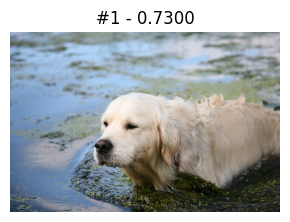

  2. Score: 0.7279, Image: ball_623.jpg


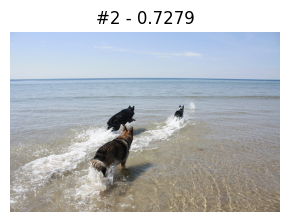

  3. Score: 0.7249, Image: water_682.jpg


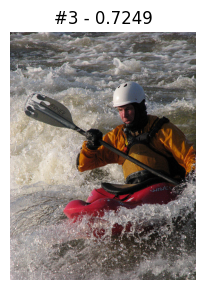

  4. Score: 0.7084, Image: water_898.jpg


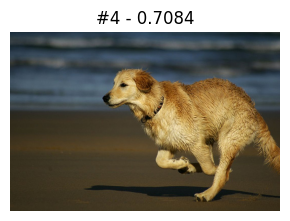

  5. Score: 0.6977, Image: water_1016.jpg


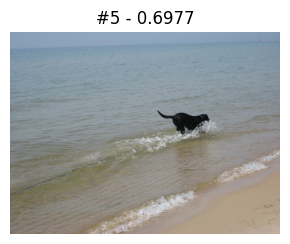


Test #2: Recherche d'images pour 'a red ball on the grass'
----------------------------------------


  1. Score: 0.7403, Image: bike_281.jpg


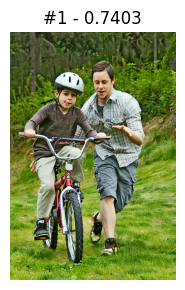

  2. Score: 0.7330, Image: water_502.jpg


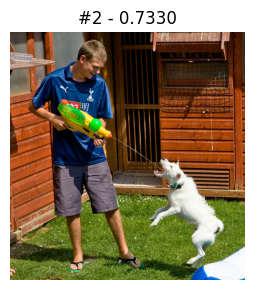

  3. Score: 0.7239, Image: ball_259.jpg


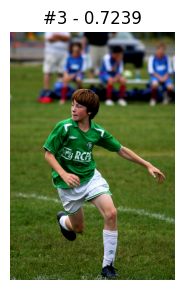

  4. Score: 0.7223, Image: ball_538.jpg


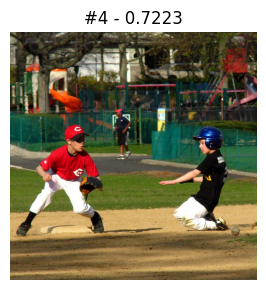

  5. Score: 0.7152, Image: ball_370.jpg


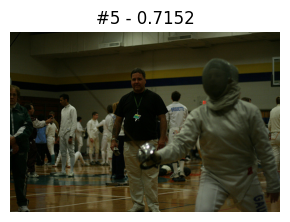


Test #3: Recherche d'images pour 'a bicycle on the street'
----------------------------------------


  1. Score: 0.7934, Image: bike_131.jpg


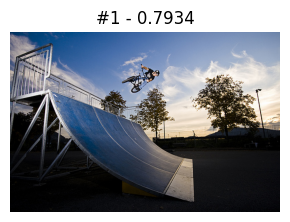

  2. Score: 0.7909, Image: bike_387.jpg


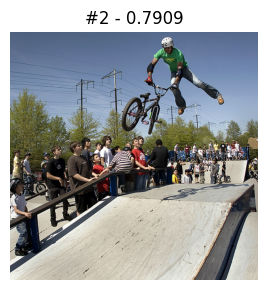

  3. Score: 0.7410, Image: bike_233.jpg


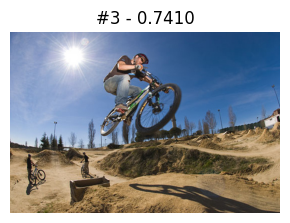

  4. Score: 0.7369, Image: bike_186.jpg


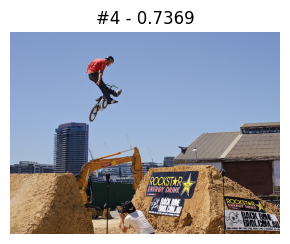

  5. Score: 0.7361, Image: bike_178.jpg


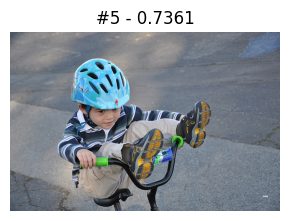


Test #4: Recherche d'images pour 'a group of cyclists'
----------------------------------------


  1. Score: 0.7531, Image: bike_273.jpg


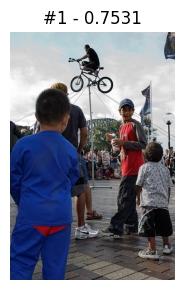

  2. Score: 0.7524, Image: bike_236.jpg


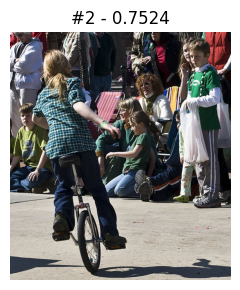

  3. Score: 0.7372, Image: bike_287.jpg


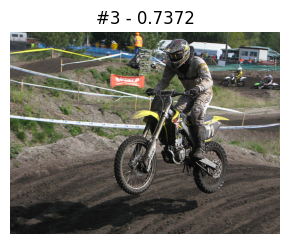

  4. Score: 0.7327, Image: bike_311.jpg


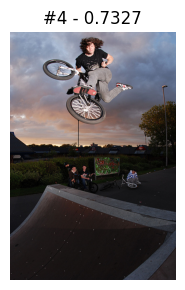

  5. Score: 0.7253, Image: bike_052.jpg


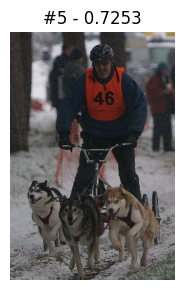


Test avec une image:
----------------------------------------
Image requête: dog_004.jpg


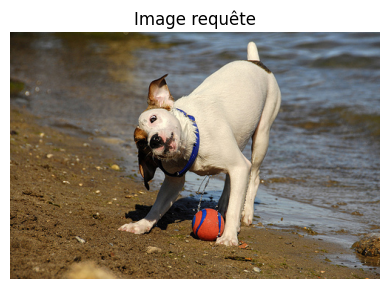

  1. Score: 0.7716
     Texte: A sleek black dog, its fur glistening in the sunlight filtering through the tree...
     Image associée: dog_004.jpg
  2. Score: 0.7633
     Texte: A rugged off-road motorcycle navigates through a babbling brook, its tires kicki...
     Image associée: bike_016.jpg
  3. Score: 0.7427
     Texte: A sleek black dog, its fur glistening in the sunlight, proudly carries a red and...
     Image associée: dog_810.jpg
  4. Score: 0.7330
     Texte: A cyclist, likely on their way to work or school, pedals down the tree-lined str...
     Image associée: bike_381.jpg
  5. Score: 0.7248
     Texte: A woman in a pink hat and navy blue coat pedals down a winding suburban street, ...
     Image associée: bike_033.jpg

Tests terminés avec succès!


In [34]:
def display_search_results(query, results, query_type="text"):
    """
    Affiche les résultats de recherche de manière lisible
    
    Args:
        query: Requête originale
        results: Liste de résultats (chemin_image, score) ou (texte, score, image_path)
        query_type: Type de requête ("text" ou "image")
    """
    print(f"\n{'='*60}")
    if query_type == "text":
        print(f"RECHERCHE D'IMAGES PAR TEXTE")
        print(f"Requête: '{query}'")
        print(f"{'='*60}")
        
        # Afficher les résultats
        for i, (image_path, score) in enumerate(results, 1):
            print(f"\nRésultat #{i}:")
            print(f"  Score de similarité: {score:.4f}")
            print(f"  Chemin de l'image: {image_path}")
            
            # Extraire le nom de fichier
            filename = os.path.basename(image_path)
            print(f"  Fichier: {filename}")
            
            # Essayer d'afficher l'image si possible
            try:
                img = mpimg.imread(image_path)
                plt.figure(figsize=(4, 4))
                plt.imshow(img)
                plt.title(f"Résultat #{i} - Score: {score:.4f}")
                plt.axis('off')
                plt.tight_layout()
                plt.show()
            except:
                print(f"  (Impossible d'afficher l'image)")
    
    elif query_type == "image":
        print(f"RECHERCHE DE TEXTES PAR IMAGE")
        print(f"Requête image: {query}")
        print(f"{'='*60}")
        
        # Afficher l'image requête
        try:
            img = mpimg.imread(query)
            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.title("Image requête")
            plt.axis('off')
            plt.tight_layout()
            plt.show()
        except:
            print(f"(Impossible d'afficher l'image requête)")
        
        # Afficher les résultats textuels
        for i, (text, score, associated_image) in enumerate(results, 1):
            print(f"\nRésultat #{i}:")
            print(f"  Score de similarité: {score:.4f}")
            print(f"  Texte: {text}")
            print(f"  Image associée: {os.path.basename(associated_image)}")
    
    print(f"{'='*60}")

def test_retrieval_system(retriever, test_queries=None):
    """
    Teste le système de recherche avec des requêtes prédéfinies
    
    Args:
        retriever: Instance de CLIPRetriever
        test_queries: Liste de requêtes de test (si None, utilise les requêtes par défaut)
    """
    if test_queries is None:
        test_queries = [
            "a dog running in the water",
            "a red ball on the grass",
            "a bicycle on the street",
            "a group of cyclists"
        ]
    
    print("TEST DU SYSTÈME DE RECHERCHE CLIP")
    print("="*60)
    
    for i, query in enumerate(test_queries, 1):
        print(f"\nTest #{i}: Recherche d'images pour '{query}'")
        print("-"*40)
        
        try:
            # Recherche d'images par texte
            results = retriever.search_images_by_text(query, top_k=5)
            
            # Afficher les résultats
            for j, (image_path, score) in enumerate(results, 1):
                print(f"  {j}. Score: {score:.4f}, Image: {os.path.basename(image_path)}")
                
                # Afficher les 5 premières images
                if j <= 5:
                    try:
                        img = mpimg.imread(image_path)
                        plt.figure(figsize=(3, 3))
                        plt.imshow(img)
                        plt.title(f"#{j} - {score:.4f}")
                        plt.axis('off')
                        plt.tight_layout()
                        plt.show()
                    except:
                        pass
                        
        except Exception as e:
            print(f"  Erreur: {e}")
    
    # Test avec une image
    print(f"\nTest avec une image:")
    print("-"*40)
    
    # Prendre une image au hasard de la galerie
    random_image_idx = np.random.randint(0, len(retriever.image_paths))
    test_image = retriever.image_paths[random_image_idx]
    
    print(f"Image requête: {os.path.basename(test_image)}")
    
    try:
        # Afficher l'image requête
        img = mpimg.imread(test_image)
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title("Image requête")
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        # Recherche de textes par image
        results = retriever.search_texts_by_image(test_image, top_k=5)
        
        # Afficher les résultats
        for j, (text, score, associated_image) in enumerate(results, 1):
            print(f"  {j}. Score: {score:.4f}")
            print(f"     Texte: {text[:80]}...")
            print(f"     Image associée: {os.path.basename(associated_image)}")
            
    except Exception as e:
        print(f"  Erreur: {e}")
    
    print("\n" + "="*60)
    print("Tests terminés avec succès!")

# Exécuter les tests
test_retrieval_system(retriever)

Pour faire la même chose avec le texte, vous pouvez sauvegarder les embeddings en vous inspirant du code suivant :   
```python
# Sauvegarde compressée de l'index texte
text_index_path = os.path.join(model_dir, "text_index.npz")
np.savez_compressed(
    text_index_path,
    embeds=text_embeds.astype("float32"),
    captions=np.array(captions, dtype=np.str_),
    image_paths=caps_df["image_path"].astype(str).to_numpy(dtype=np.str_)
)
print("Index texte sauvegardé:",
      text_index_path, " - shape :", text_embeds.shape)
```       

Chargement des index...
Chargement du modèle CLIP...



Résultats pour : 'a dog in the water'


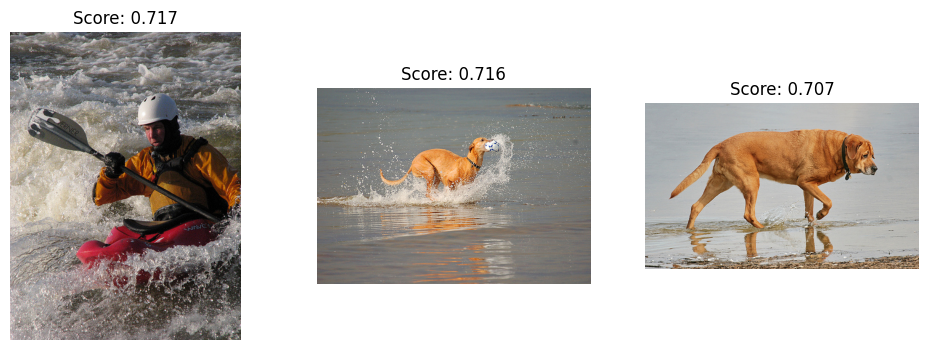


Résultats pour : 'it’s a horse that enters a pub'


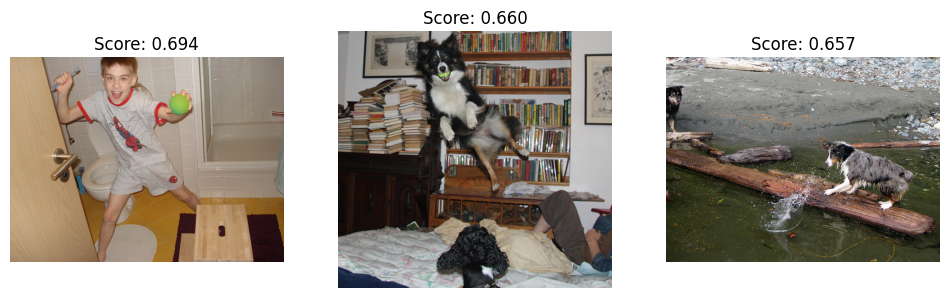

In [35]:

# =============================================================================
# 1. CLASSES PERSONNALISÉES (DOIVENT ÊTRE ENREGISTRÉES AVEC LE MÊME NOM)
# =============================================================================

@tf.keras.utils.register_keras_serializable(package="Custom")
class SmallBERT(tf.keras.Model):
    def __init__(self, sequence_length=32, vocab_size=10000, embed_dim=128, 
                 num_heads=4, ff_dim=256, num_layers=2, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.num_layers = num_layers
        self.pos_embedding = PositionalEmbedding(sequence_length, vocab_size, embed_dim)
        self.transformer_blocks = [TransformerBlock(embed_dim, num_heads, ff_dim) for _ in range(num_layers)]
        self.layernorm = layers.LayerNormalization(epsilon=1e-6)
        self.dropout = layers.Dropout(0.1)

    def call(self, inputs, training=False):
        x = self.pos_embedding(inputs)
        for block in self.transformer_blocks:
            x = block(x, training=training)
        x = self.layernorm(x)
        return self.dropout(x, training=training)

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length, "vocab_size": self.vocab_size,
            "embed_dim": self.embed_dim, "num_heads": self.num_heads,
            "ff_dim": self.ff_dim, "num_layers": self.num_layers,
        })
        return config

@tf.keras.utils.register_keras_serializable(package="Custom")
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.position_embeddings = layers.Embedding(input_dim=sequence_length, output_dim=embed_dim)
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(0, length)
        return self.token_embeddings(inputs) + self.position_embeddings(positions)

    def get_config(self):
        config = super().get_config()
        config.update({"sequence_length": self.sequence_length, "vocab_size": self.vocab_size, "embed_dim": self.embed_dim})
        return config

@tf.keras.utils.register_keras_serializable(package="Custom")
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim)])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

@tf.keras.utils.register_keras_serializable(package="Custom")
class MaskedMean(layers.Layer):
    def call(self, inputs):
        seq_out, token_ids = inputs
        mask = tf.cast(tf.not_equal(token_ids, 0), seq_out.dtype)
        mask = tf.expand_dims(mask, -1)
        return tf.reduce_sum(seq_out * mask, axis=1) / tf.maximum(tf.reduce_sum(mask, axis=1), 1e-9)

@tf.keras.utils.register_keras_serializable(package="Custom")
class L2Normalize(layers.Layer):
    def __init__(self, axis=-1, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis
    def call(self, inputs): return tf.math.l2_normalize(inputs, axis=self.axis)

@tf.keras.utils.register_keras_serializable(package="clip")
class ClipLossLayer(layers.Layer):
    def __init__(self, temperature=0.07, **kwargs):
        super().__init__(**kwargs)
        self.temperature = temperature
    def call(self, inputs):
        img, txt = inputs
        logits = tf.matmul(img, txt, transpose_b=True) / self.temperature
        labels = tf.range(tf.shape(logits)[0])
        li = tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
        lt = tf.keras.losses.sparse_categorical_crossentropy(labels, tf.transpose(logits), from_logits=True)
        self.add_loss(tf.reduce_mean(li + lt) / 2.0)
        return (img, txt)

# =============================================================================
# 2. CLASSE D'INFÉRENCE CLIP
# =============================================================================

class EasyCLIP:
    def __init__(self, models_dir="models_forclip", images_dir="flickr_subset2/images"):
        self.models_dir = models_dir
        self.images_dir = images_dir
        
        # Objets pour le chargement Keras
        self.custom_objs = {
            "SmallBERT": SmallBERT, "PositionalEmbedding": PositionalEmbedding,
            "TransformerBlock": TransformerBlock, "MaskedMean": MaskedMean,
            "L2Normalize": L2Normalize, "ClipLossLayer": ClipLossLayer
        }

        # 1. Chargement des Index
        print("Chargement des index...")
        img_data = np.load(os.path.join(models_dir, "image_index.npz"))
        self.img_embeds = img_data["embeddings"]
        self.img_paths = img_data["paths"]
        
        # 2. Chargement du Vectorizer
        self._init_vectorizer()

        # 3. Chargement de l'encodeur de texte
        print("Chargement du modèle CLIP...")
        full_model = tf.keras.models.load_model(
            os.path.join(models_dir, "best_clip_model.h5"),
            custom_objects=self.custom_objs,
            compile=False
        )
        self.text_encoder = full_model.get_layer("text_encoder")

    def _init_vectorizer(self):
        vocab_path = os.path.join(self.models_dir, "vocab.txt")
        self.vectorizer = TextVectorization(max_tokens=10000, output_sequence_length=32)
        with open(vocab_path, 'r', encoding='utf-8') as f:
            vocab = [line.strip() for line in f]
        self.vectorizer.set_vocabulary(vocab)

    def search(self, query_text, top_k=3):
        # Encodage de la requête
        tokens = self.vectorizer([query_text])
        query_emb = self.text_encoder.predict(tokens, verbose=0)
        query_emb = query_emb / np.linalg.norm(query_emb, axis=1, keepdims=True)
        
        # Calcul des scores (similarité cosinus)
        scores = np.dot(query_emb, self.img_embeds.T)[0]
        top_indices = np.argsort(scores)[::-1][:top_k]
        
        # Affichage
        print(f"\nRésultats pour : '{query_text}'")
        plt.figure(figsize=(12, 4))
        for i, idx in enumerate(top_indices):
            ax = plt.subplot(1, top_k, i + 1)
            img = mpimg.imread(self.img_paths[idx])
            ax.imshow(img)
            ax.set_title(f"Score: {scores[idx]:.3f}")
            ax.axis("off")
        plt.show()

# =============================================================================
# 3. LANCEMENT
# =============================================================================
engine = EasyCLIP()
engine.search("a dog in the water")
engine.search("it’s a horse that enters a pub")


Il ne vous reste plus qu'à définir une requête comme par exemple "A group of cyclists", et retrouver par rapport à son embedding quelles sont les images les plus proches. Vous pouvez appliquer le même principe en donnant une image comme requête.   

**Astuces :**   
- N'oubliez pas ce qu'attend l'entrée de la partie encodeur de votre sous-modèle texte.
- si `embeds` correspond à votre tableau d'embeddings, avec une forme (N,D) et `q` correspond à la prédiction de votre sous modèle d'encodeur de texte, i.e. l'embedding de votre requête avec une forme (1,D), alors si on utilise l'opérateur produit matriciel de NumPy (`@`), `q @ embeds.T` calcule le produit scalaire entre q et chaque embedding d'image de la galerie (i.e. (1, D) X (D, N) donne (1, N)). Si vous n'avez pas oublié de normaliser vos sortie le produit scalaire est égal à la similarité cosinus. En ecrivant `scores = (q @ embeds.T)[0]` vous récupérerez la matrice (1, N) en un simple vecteur de taille N qu'il suffira de trier pour avoir les meilleurs résultat au début (e.g. [Argsort](https://numpy.org/devdocs/reference/generated/numpy.argsort.html)). Simple non ?